Cells must be run in order.

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn import linear_model
import numpy as np
import warnings
import matplotlib.ticker as ticker
from matplotlib import cm
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import prince

# custom
import functions as functions

# Ignore specific warnings from scipygit
warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy")

pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Initialize

Name of political dimensions.

In [92]:
Dimensions = ['Left-Right', 'Immigration', 'Environment', 'Social liberalism', 'Redistribution','Anti-elitism', 'EU integration', 'Direct democracy']

Data path.

In [93]:
data_path = 'data/'

Path to ESS results obtained in R.

In [94]:
ess_path = 'ESS_results/'

## Esthetics

Where to save figures.

In [95]:
figpath  = './plots_test/'

Define general Matplotlib style.

In [96]:
def reset_plot_style():
    
    mpl.style.use('seaborn-v0_8-whitegrid')  # or 'ggplot', 'bmh', 'fivethirtyeight'
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.bottom'] = True
    plt.rcParams['axes.spines.left'] = True

    plt.rcParams['axes.grid'] = False
    mpl.rcParams['mathtext.fontset'] = 'stix'
    mpl.rcParams['font.family'] = 'STIXGeneral' #'Lato'

    # font size
    mpl.rcParams['axes.labelsize'] = 16
    mpl.rcParams['xtick.labelsize'] = 14
    mpl.rcParams['ytick.labelsize'] = 14
    mpl.rcParams['legend.fontsize'] = 14
    mpl.rcParams['legend.title_fontsize'] = 18
    mpl.rcParams['figure.titlesize'] = 18
    mpl.rcParams['axes.titlesize'] = 18

    # ticks
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['xtick.top'] = False
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.right'] = False
    plt.rcParams['xtick.major.size'] = 6
    plt.rcParams['ytick.major.size'] = 6
    plt.rcParams['xtick.major.width'] = 1
    plt.rcParams['ytick.major.width'] = 1
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'

In [97]:
reset_plot_style()

Define a color for each data source.

In [98]:
cmap = plt.get_cmap('rainbow_r')
df_color = {'X': cmap(0), 'ESS': cmap(.75), 'CHES': cmap(.375)}

Labeling dimensions for plots.

In [99]:
axis_label_neg = {'Left-Right': 'Left', 'EU integration': 'EU+', 'Immigration':'Immig+', 'Anti-elitism':'Elitist',
                'Social liberalism': 'SocLib+', 'Environment': 'Env+', 'Redistribution': 'Redist+',
                'Direct democracy': 'DirDem-'}

axis_label_pos = {'Left-Right': 'Right', 'EU integration': 'EU-', 'Immigration':'Immig-', 'Anti-elitism':'Anti-elite',
                'Social liberalism': 'SocLib-', 'Environment': 'Env-', 'Redistribution': 'Redist-',
                'Direct democracy': 'DirDem+'}

axis_label = {'Left-Right':'Left <---> Right', 'Immigration':'Pro <---> Anti', 'Environment':'Pro <---> Anti', 'Social liberalism':'Pro <---> Anti',
          'Anti-elitism':'Elitist <---> Anti-elite', 'EU integration':'Pro <---> Anti', 'Direct democracy':'Anti <---> Pro', 'Redistribution':'Pro <---> Anti'}

Labels for data sources.

In [100]:
DataLabel = {'X':'X panel', 'ESS':'ESS panel', 'CHES':'CHES parties'}

Choose markers.

In [101]:
Marker = {'X':'o', 'ESS':'s', 'CHES':'d'}

Short labels for political dimensions.

In [102]:
short_label = {'Left-Right':'LR',
'Immigration':'Immig',
'Environment':'Env',
'Social liberalism': 'SocLib',
'Redistribution':'Redist',
'Anti-elitism':'AE',
'EU integration':'EU',
'Direct democracy':'DirDem'}

## Load and pre-process X data

Get political positions of users.

In [103]:
df_x = pd.read_csv(data_path + 'followers_positions.csv')

In [104]:
df_x

,pseudo_id,lrgen_19,corrupt_salience_19,people_vs_elite_19,immigrate_policy_19,sociallifestyle_19,nationalism_19,antielite_salience_23,eu_position_23,lrecon_23,refugees_23,galtan_23,environment_19,lrecon_19,antielite_salience_19,eu_position_19,galtan_19
0,user_0,3.015,5.360,6.196,5.458,3.124,4.525,8.137,4.242,3.677,6.458,4.187,4.624,2.291,9.431,3.117,4.637
1,user_1,3.079,4.338,5.188,4.006,2.234,3.938,6.658,4.847,3.113,6.761,3.778,3.662,2.575,6.832,5.085,3.866
2,user_2,9.582,4.604,4.014,9.579,9.070,9.683,8.375,2.582,6.935,2.867,9.189,6.834,7.869,7.080,2.916,8.581
3,user_3,3.187,5.358,6.063,5.693,3.332,4.719,7.942,4.410,4.028,6.409,4.451,4.877,2.428,9.490,3.015,4.828
4,user_4,5.509,5.433,5.545,7.473,5.509,6.866,8.448,3.484,5.236,4.713,6.477,5.829,4.153,9.458,2.094,6.456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,4.711,5.210,5.405,3.447,4.513,6.652,5.345,4.378,7.078,4.362,4.990,3.232,7.837,4.601,4.694
978046,user_978929,7.794,5.112,5.047,7.077,6.005,6.428,5.778,5.717,6.000,6.321,6.099,5.633,6.819,5.966,6.506,5.853
978047,user_978930,7.932,4.493,4.144,7.498,6.721,7.037,5.928,5.403,6.518,5.753,6.793,6.042,7.100,5.616,6.088,6.473
978048,user_978931,3.680,5.556,6.027,6.512,4.080,5.524,8.410,3.926,4.545,5.754,5.264,5.402,2.695,10.142,2.104,5.503


Restrict to variables of interest and rename political dimensions.

In [105]:
VariableName = {'lrgen_19': 'Left-Right', 
                'antielite_salience_23': 'Anti-elitism', 
                'eu_position_23': 'EU integration', 
                'sociallifestyle_19': 'Social liberalism', 
                'environment_19': 'Environment', 
                'immigrate_policy_19': 'Immigration',
                'people_vs_elite_19': 'Direct democracy', 
                'lrecon_23': 'Redistribution'}

In [106]:
df_x = df_x[['pseudo_id'] + list(VariableName.keys())]

In [107]:
df_x = df_x.rename(columns = {var: name for var,name in VariableName.items()})

Rescale outliers.

In [108]:
print('Percentage of outliers')
for dim in Dimensions:
    percent_outliers = 100*((df_x[dim]<0) | (df_x[dim]>10)).sum() / df_x.shape[0]
    print(dim,  percent_outliers)
    df_x.loc[df_x[dim]<0, dim] = 0
    df_x.loc[df_x[dim]>10, dim] = 10

Percentage of outliers
Left-Right 3.080824088748019
Immigration 4.010633403200245
Environment 0.18986759368130462
Social liberalism 0.5901538776136189
Redistribution 0.03271816369306273
Anti-elitism 2.082817851848065
EU integration 0.9201983538673892
Direct democracy 0.022595981800521445


In [109]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution
0,user_0,3.015,8.137,4.242,3.124,4.624,5.458,6.196,3.677
1,user_1,3.079,6.658,4.847,2.234,3.662,4.006,5.188,3.113
2,user_2,9.582,8.375,2.582,9.070,6.834,9.579,4.014,6.935
3,user_3,3.187,7.942,4.410,3.332,4.877,5.693,6.063,4.028
4,user_4,5.509,8.448,3.484,5.509,5.829,7.473,5.545,5.236
...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,5.345,3.447,4.990,5.405,5.210,4.378
978046,user_978929,7.794,5.778,5.717,6.005,5.633,7.077,5.047,6.000
978047,user_978930,7.932,5.928,5.403,6.721,6.042,7.498,4.144,6.518
978048,user_978931,3.680,8.410,3.926,4.080,5.402,6.512,6.027,4.545


Reverse EU integration ordering.

In [110]:
df_x['EU integration'] = 10.0 - df_x['EU integration']

Get activity and popularity metrics.

In [111]:
df_actipop = pd.read_csv(data_path + 'followers_activity.csv')

Merge with political positions.

In [112]:
df_x = df_x.merge(df_actipop, on='pseudo_id')

In [113]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution,mean_tweets_per_day,followers,followees
0,user_0,3.015,8.137,5.758,3.124,4.624,5.458,6.196,3.677,1.272,47,292
1,user_1,3.079,6.658,5.153,2.234,3.662,4.006,5.188,3.113,0.000,1,62
2,user_2,9.582,8.375,7.418,9.070,6.834,9.579,4.014,6.935,0.000,0,105
3,user_3,3.187,7.942,5.590,3.332,4.877,5.693,6.063,4.028,0.001,0,509
4,user_4,5.509,8.448,6.516,5.509,5.829,7.473,5.545,5.236,0.070,66,263
...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,4.655,3.447,4.990,5.405,5.210,4.378,0.031,113,692
978046,user_978929,7.794,5.778,4.283,6.005,5.633,7.077,5.047,6.000,0.011,9,5002
978047,user_978930,7.932,5.928,4.597,6.721,6.042,7.498,4.144,6.518,0.057,36,131
978048,user_978931,3.680,8.410,6.074,4.080,5.402,6.512,6.027,4.545,0.063,12,191


In [114]:
print('Number of rows containing NaNs: ', df_x.isna().any(axis=1).sum())

Number of rows containing NaNs:  0


Drop followees column (unused).

In [115]:
df_x = df_x.drop(columns='followees')

Clean memory: delete activity and popularity df.

In [116]:
del df_actipop

## Load ESS data

In [117]:
df_ess = pd.read_csv(data_path + 'ESS11_preprocessed.csv')

Range of values along each dimension.

In [118]:
ess_label_range = {
        "Direct democracy": [1, 2, 3, 4, 5],
        "Environment": [1, 2, 3, 4, 5, 6],
        "Left-Right": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "EU integration": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Anti-elitism": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Immigration": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Social liberalism": [1, 2, 3, 4, 5],
        "Redistribution": [1, 2, 3, 4, 5],
        "Online political actiivty": [1,2]
    }

Load weighted counts of respondent.

In [119]:
ess_path = 'ESS_results/'

In [120]:
ess_counts_full = pd.read_csv(ess_path + 'weighted_counts_by_variable.csv')

In [121]:
ess_counts_full['variable'] = [d.replace('.', ' ') for d in ess_counts_full['variable'].values]
ess_counts_full['variable'] = ess_counts_full['variable'].replace({'Left Right':'Left-Right',
                                                                    'Anti elitism':'Anti-elitism'
                                                                    })

Load correlation matrix.

In [122]:
corrmat_ESS = pd.read_csv(ess_path + 'Corr_matrix.csv')

In [123]:
corrmat_ESS['Unnamed: 0'] = [d.replace('.', ' ') for d in corrmat_ESS['Unnamed: 0'].values]
corrmat_ESS['Unnamed: 0'] = corrmat_ESS['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
corrmat_ESS = corrmat_ESS.set_index(corrmat_ESS['Unnamed: 0'].values).drop(columns='Unnamed: 0')
corrmat_ESS.columns = corrmat_ESS.index

In [124]:
corrmat_ESS

,Left-Right,Immigration,Environment,Social liberalism,Redistribution,Anti-elitism,EU integration,Direct democracy
Left-Right,1.000,0.389,0.160,0.112,0.245,-0.002,0.167,0.056
Immigration,0.389,1.000,0.117,0.064,0.101,0.202,0.263,0.230
Environment,0.160,0.117,1.000,0.067,0.130,0.027,0.109,-0.018
Social liberalism,0.112,0.064,0.067,1.000,0.113,-0.059,0.040,0.026
Redistribution,0.245,0.101,0.130,0.113,1.000,-0.047,-0.003,-0.090
Anti-elitism,-0.002,0.202,0.027,-0.059,-0.047,1.000,0.271,0.406
EU integration,0.167,0.263,0.109,0.040,-0.003,0.271,1.000,0.246
Direct democracy,0.056,0.230,-0.018,0.026,-0.090,0.406,0.246,1.000


Load p-values of correlation matrix.

In [125]:
pval_ESS = pd.read_csv(ess_path + 'Corr_pval.csv')

In [126]:
pval_ESS['Unnamed: 0'] = [d.replace('.', ' ') for d in pval_ESS['Unnamed: 0'].values]
pval_ESS['Unnamed: 0'] = pval_ESS['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                         'Anti elitism':'Anti-elitism'})
pval_ESS = pval_ESS.set_index(pval_ESS['Unnamed: 0'].values).drop(columns='Unnamed: 0')
pval_ESS.columns = pval_ESS.index

## Load CHES data

In [127]:
ches2023 = pd.read_csv('data/CHES_Ukraine_March_2024.csv')
ches2019 = pd.read_csv('data/CHES2019V3.csv')

In [128]:
ches2023 = ches2023[ches2023.country=='France']
ches2019 = ches2019[ches2019.country==6]

In [129]:
ches2019 = ches2019[['party','lrgen','sociallifestyle','environment','immigrate_policy','people_vs_elite']]
ches2019 = ches2019.rename(columns={c: c+'_19' for c in ches2019.columns if c!='party'})

In [130]:
ches2023 = ches2023[['party','antielite_salience','eu_position','lrecon', 'seatperc']]
ches2023 = ches2023.rename(columns={c: c+'_23' for c in ches2023.columns if c not in ('party','seatperc')})

In [131]:
party_map = {p: p for p in set(ches2019.party.unique()).union( set(ches2023.party.unique()))}
party_map['REM; RE'] = 'RE'
party_map['LREM'] = 'RE'
party_map['FI'] = 'LFI'

ches2019['party'] = ches2019['party'].map(party_map)
ches2023['party'] = ches2023['party'].map(party_map)

In [132]:
ches = ches2019.merge(ches2023, how='inner', on='party')

In [133]:
ches = ches.rename(columns = {var: name for var,name in VariableName.items()})

In [134]:
ches["EU integration"] = (ches["EU integration"] - 1) * 10 / 6
ches["EU integration"] = 10- ches["EU integration"]

In [135]:
ches

,party,Left-Right,Social liberalism,Environment,Immigration,Direct democracy,Anti-elitism,EU integration,Redistribution,seatperc
0,PCF,1.125,1.625,3.857,3.250,4.125,6.500,6.667,2.000,2.080
1,PS,3.000,0.875,4.000,2.750,4.125,4.000,2.500,3.500,4.850
2,EELV,2.500,0.625,1.625,1.625,5.750,4.333,2.778,2.500,5.370
3,LR,7.875,7.625,7.250,7.875,2.286,4.667,4.444,8.167,10.570
4,RN,9.750,7.750,7.250,9.875,7.750,8.833,8.333,6.000,15.420
5,MoDem,6.125,4.250,6.143,5.375,3.375,2.500,0.556,6.667,8.320
6,RE,6.333,2.500,5.167,5.667,3.333,2.333,0.556,6.833,34.140
7,LFI,1.250,1.000,3.875,4.000,7.000,8.667,6.944,1.800,12.310
8,DLF,9.000,8.400,6.500,9.333,4.750,9.167,9.444,6.000,0.170


In [136]:
mps = pd.read_csv('/mnt/data1/antoinevendeville/EPO_FR_2023_data_article/min_followers_0/Publishable/mps_positions.csv')

In [137]:
mp_count = mps[['party','pseudo_id']].groupby('party').count().reset_index().rename(columns={'pseudo_id':'n_twitter_accounts'})

In [138]:
ches = ches.merge(mp_count, on='party', how='inner')

In [139]:
ches

,party,Left-Right,Social liberalism,Environment,Immigration,Direct democracy,Anti-elitism,EU integration,Redistribution,seatperc,n_twitter_accounts
0,PCF,1.125,1.625,3.857,3.250,4.125,6.500,6.667,2.000,2.080,25
1,PS,3.000,0.875,4.000,2.750,4.125,4.000,2.500,3.500,4.850,84
2,EELV,2.500,0.625,1.625,1.625,5.750,4.333,2.778,2.500,5.370,26
3,LR,7.875,7.625,7.250,7.875,2.286,4.667,4.444,8.167,10.570,172
4,RN,9.750,7.750,7.250,9.875,7.750,8.833,8.333,6.000,15.420,87
5,MoDem,6.125,4.250,6.143,5.375,3.375,2.500,0.556,6.667,8.320,52
6,RE,6.333,2.500,5.167,5.667,3.333,2.333,0.556,6.833,34.140,193
7,LFI,1.250,1.000,3.875,4.000,7.000,8.667,6.944,1.800,12.310,72
8,DLF,9.000,8.400,6.500,9.333,4.750,9.167,9.444,6.000,0.170,1


# Distribution of panelists along political dimensions
Figure 1.

Discretize X panelists.

In [140]:
for dim in Dimensions:
    df_x[dim + '_bin'] = functions.discretized(df_x, dim, ess_label_range)

Plots distributions.

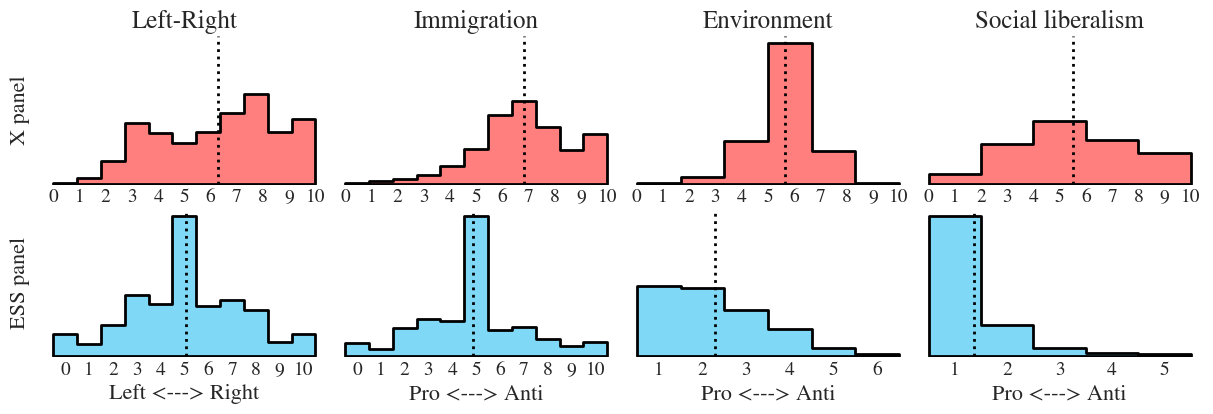

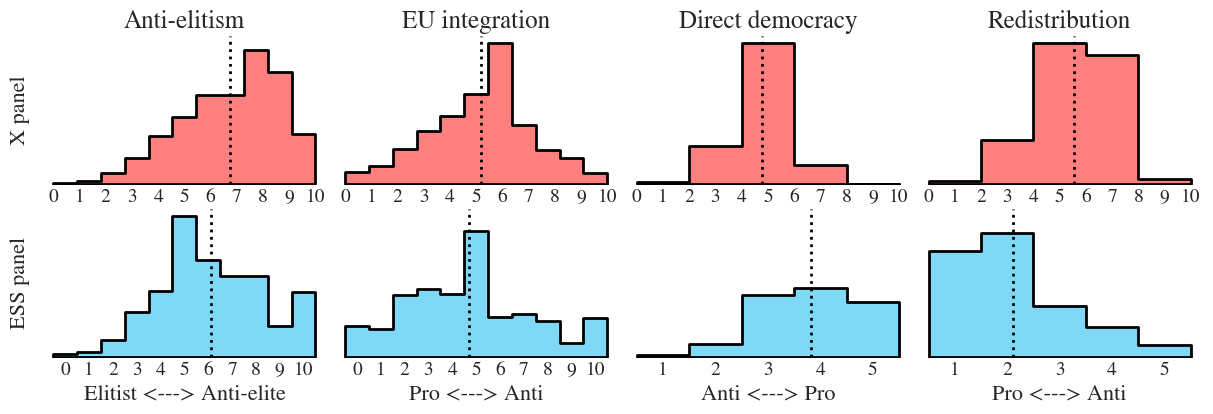

In [141]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Get the mass in each bin
        Counts['X'] = functions.get_x_counts(df_x, dim)
        Counts['ESS'] = functions.get_ess_counts(ess_counts_full, dim)

        for j,label in enumerate(('X', 'ESS')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot histogram
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label], edgecolor='none', discrete=True, alpha=.5, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', discrete=True, alpha=1, ax=ax)

            # xticks for X panel
            if label=='X':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            # esthetics
            if j==1:
                ax.set_xticks(ess_label_range[dim])
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            # axe lines
            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    plt.tight_layout(pad=.2)
    plt.savefig(figpath + f'histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

Compute and show Wasserstein distance between X and ESS panel for each dimension.

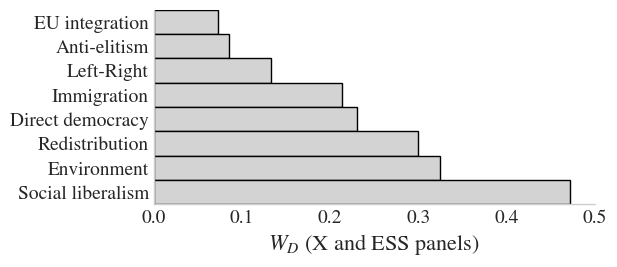

In [142]:
WD = dict()

for dim in Dimensions:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_x, dim)
    ess_counts = functions.get_ess_counts(ess_counts_full, dim)

    # compute theoretical max distance
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])

    # compute
    wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
    WD[dim] = wd / wd_max
    
# Step 2: Set y='Dimension' as a categorical with the right order
dimension_order = [dim for dim,wd in sorted(WD.items(), key=lambda x:x[1])]

plot_data = pd.DataFrame({'Dimension':WD.keys(), 'WD':WD.values()})
plot_data['Dimension'] = pd.Categorical(
    plot_data['Dimension'], 
    categories=dimension_order, 
    ordered=True
)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(6,2.5))
sns.barplot(data=plot_data, y='Dimension', x='WD', color='lightgrey', width=1, edgecolor='k')

# esthetics
plt.ylabel('')
plt.xlim(0,.5)
plt.tick_params(length=0)
plt.xlabel(fr'$W_D$ (X and ESS panels)')
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'WD.png', dpi=300)
plt.show()
plt.close()

Compute and show polarization along each dimension.

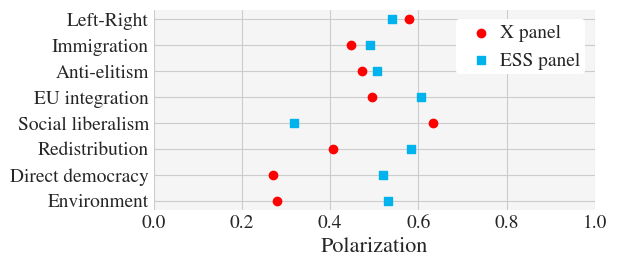

In [143]:
Dimensions_ordered = ['Environment', 'Direct democracy', 'Redistribution', 'Social liberalism', 'EU integration', 'Anti-elitism', 'Immigration', 'Left-Right']

# Combine all data into one list
data_x = {'Dimension':list(), 'Polarization':list()}
data_ess = {'Dimension':list(), 'Polarization':list()}

for dim in Dimensions_ordered:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_x, dim)
    ess_counts = functions.get_ess_counts(ess_counts_full, dim)

    # compute pola
    pola_x = functions.polarization_from_counts_df(x_counts)
    pola_ess = functions.polarization_from_counts_df(ess_counts)

    # append
    data_x['Dimension'].append(dim)
    data_ess['Dimension'].append(dim)
    data_x['Polarization'].append(pola_x)
    data_ess['Polarization'].append(pola_ess)

# create dfs
data_x = pd.DataFrame(data_x)
data_ess = pd.DataFrame(data_ess)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(6,2.5))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Polarization'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], label=DataLabel['X'])
plt.scatter(data_ess['Polarization'], data_ess['Dimension'], color=df_color['ESS'], marker=Marker['ESS'], label=DataLabel['ESS'])

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
plt.legend(frameon=True, framealpha=1, edgecolor='none', loc='best', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Polarization')
plt.xlim(0,1)
plt.yticks(range(xaxis.size), data_x['Dimension'].values)
plt.tick_params(length=0)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'polarization.png', dpi=300)
plt.show()
plt.close()

# Analysis of correlations
Figure 2.

Get pvalues of correlations for X panel.

In [144]:
Dimensions_reordered = ['Left-Right', 'Immigration', 'Environment', 'Redistribution', 'Social liberalism', 'Anti-elitism', 'EU integration', 'Direct democracy']

In [145]:
pval_x = np.zeros((len(Dimensions_reordered), len(Dimensions_reordered)))
for i1,dim1 in enumerate(Dimensions_reordered):
    for i2,dim2 in enumerate(Dimensions_reordered):
        if i1<i2:
            stat, pval = stats.pearsonr(df_x[dim1].values, df_x[dim2].values)
            pval_x[i1,i2] = pval_x[i2,i1] = pval
pval_x = pd.DataFrame(pval_x)
pval_x.index = Dimensions_reordered
pval_x.columns = Dimensions_reordered

In [146]:
df_corr = {'X': df_x[Dimensions_reordered].corr(), 'ESS':corrmat_ESS[Dimensions_reordered].reindex(Dimensions_reordered)}

df_pval = {'X': pval_x, 'ESS':pval_ESS[Dimensions_reordered].reindex(Dimensions_reordered)}

Create matrix with significance levels.

In [147]:
significance_matrix = dict()

for name in ('X', 'ESS'):

    significance_matrix[name] = pd.DataFrame('', index=df_pval[name].index, columns=df_pval[name].columns)
    significance_matrix[name][df_pval[name] <= 0.001] = '***'
    significance_matrix[name][(df_pval[name] <= 0.01) & (df_pval[name] > 0.001)] = '**'
    significance_matrix[name][(df_pval[name] <= 0.05) & (df_pval[name] > 0.01)] = '*'

Show heatmaps.

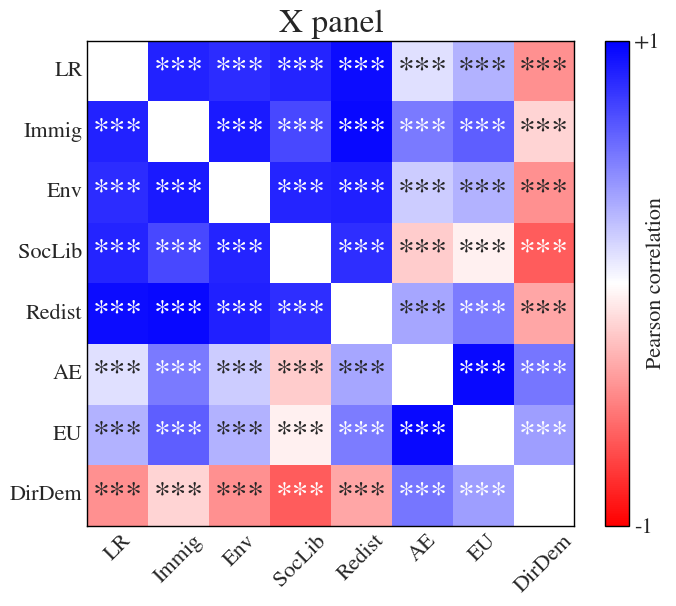

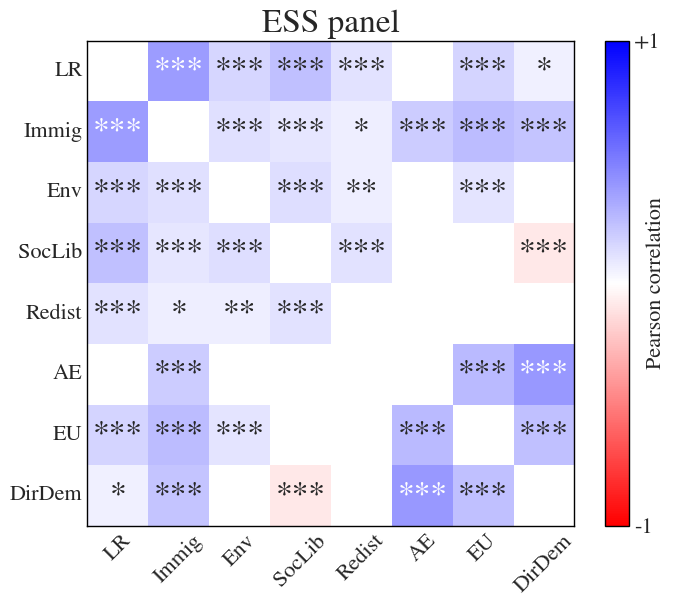

In [148]:
nan_color = 'w'

for name in ('X', 'ESS'):

    fig,ax = plt.subplots(figsize=(7,6))

    df = df_corr[name].mask(np.eye(df_corr[name].shape[0], dtype=bool)).mask(df_pval[name]>.05)

    cmap = plt.get_cmap('bwr_r').copy()
    cmap.set_bad(color=nan_color)
    sns.heatmap(df, vmin=-1, vmax=1, cmap=cmap, cbar_kws={'label':'Pearson correlation', 'ticks':[-1,1]}, 
                annot=significance_matrix[name].values, fmt='', cbar=True, ax=ax, annot_kws={'fontsize':24}) # set annot=False to remove significance levels

    # Get the colorbar and add border
    cbar = ax.collections[0].colorbar
    cbar.outline.set_visible(True)           # show border
    cbar.outline.set_edgecolor('black')      # border color
    cbar.outline.set_linewidth(1)          # border thickness
    cbar.set_label('Pearson correlation', fontsize=16, labelpad=-10) # Change colorbar label font size
    cbar.set_ticklabels(['-1', '+1'])
    cbar.ax.tick_params(labelsize=16, length=0) # Change colorbar tick label font size

    # esthetics
    ax.set_title(DataLabel[name], fontsize=24)
    ax.tick_params(axis='x', labelsize=16, rotation=45)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xticklabels([short_label[dim] for dim in Dimensions])
    ax.set_yticklabels([short_label[dim] for dim in Dimensions])
    ax.tick_params(axis='both', length=0)

    for pos in ('top', 'bottom', 'left', 'right'):
      ax.spines[pos].set_visible(True)
      ax.spines[pos].set_color('k')
      ax.spines[pos].set_linewidth(1)

    # save
    plt.tight_layout(pad=.5)
    plt.savefig(figpath + f'correlation_{name}.png', dpi=300)
    plt.show()
    plt.close()

Compare ingroup and outgroup correlations.

In [149]:
X_ingroup_avg_corr = np.mean(list(df_corr['X'].abs().values[:5,:5][np.triu_indices(5,1)]) + list(df_corr['X'].abs().values[-3:,-3:][np.triu_indices(3,1)]))
X_outgroup_avg_corr = np.mean(df_corr['X'].abs().values[:5,-3:])

In [150]:
X_ingroup_avg_corr, X_outgroup_avg_corr, X_ingroup_avg_corr / X_outgroup_avg_corr

(np.float64(0.8068558771506091),
 np.float64(0.34701229835105246),
 np.float64(2.3251506675257927))

In [151]:
ESS_ingroup_avg_corr = np.mean(list(corrmat_ESS.abs().values[:5,:5][np.triu_indices(5,1)]) + list(corrmat_ESS.abs().values[-3:,-3:][np.triu_indices(3,1)]))
ESS_outgroup_avg_corr = np.mean(corrmat_ESS.abs().values[:5,-3:])

In [152]:
ESS_ingroup_avg_corr, ESS_outgroup_avg_corr, ESS_ingroup_avg_corr / ESS_outgroup_avg_corr

(np.float64(0.18621562527806562),
 np.float64(0.08914929576512848),
 np.float64(2.088806464255946))

## CHES correlations

In [153]:
pval_ches = np.zeros((len(Dimensions_reordered), len(Dimensions_reordered)))
for i1,dim1 in enumerate(Dimensions_reordered):
    for i2,dim2 in enumerate(Dimensions_reordered):
        if i1<i2:
            stat, pval = stats.pearsonr(ches[dim1].values, ches[dim2].values)
            pval_ches[i1,i2] = pval_ches[i2,i1] = pval
pval_ches = pd.DataFrame(pval_ches)
pval_ches.index = Dimensions_reordered
pval_ches.columns = Dimensions_reordered

In [154]:
df_corr['CHES'] = ches[Dimensions_reordered].corr()
df_pval['CHES'] = pval_ches

Create matrix with significance levels.

In [155]:
significance_matrix['CHES'] = pd.DataFrame('', index=df_pval['CHES'].index, columns=df_pval['CHES'].columns)
significance_matrix['CHES'][df_pval['CHES'] <= 0.001] = '***'
significance_matrix['CHES'][(df_pval['CHES'] <= 0.01) & (df_pval['CHES'] > 0.001)] = '**'
significance_matrix['CHES'][(df_pval['CHES'] <= 0.05) & (df_pval['CHES'] > 0.01)] = '*'

Show heatmaps.

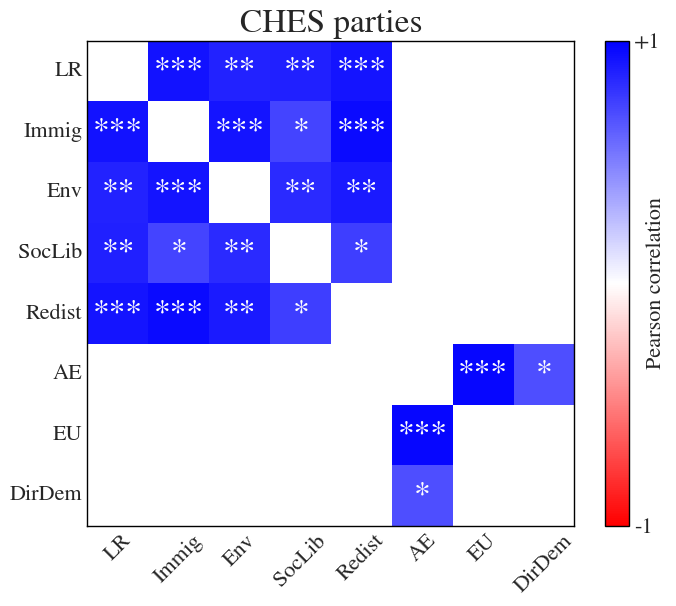

In [156]:
nan_color = 'w'

fig,ax = plt.subplots(figsize=(7,6))

df = df_corr['CHES'].mask(np.eye(df_corr['CHES'].shape[0], dtype=bool)).mask(df_pval['CHES']>.05)

cmap = plt.get_cmap('bwr_r').copy()
cmap.set_bad(color=nan_color)
sns.heatmap(df, vmin=-1, vmax=1, cmap=cmap, cbar_kws={'label':'Pearson correlation', 'ticks':[-1,1]}, 
            annot=significance_matrix['CHES'].values, fmt='', cbar=True, ax=ax, annot_kws={'fontsize':24}) # set annot=False to remove significance levels

# Get the colorbar and add border
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)           # show border
cbar.outline.set_edgecolor('black')      # border color
cbar.outline.set_linewidth(1)          # border thickness
cbar.set_label('Pearson correlation', fontsize=16, labelpad=-10) # Change colorbar label font size
cbar.set_ticklabels(['-1', '+1'])
cbar.ax.tick_params(labelsize=16, length=0) # Change colorbar tick label font size

# esthetics
ax.set_title(DataLabel['CHES'], fontsize=24)
ax.tick_params(axis='x', labelsize=16, rotation=45)
ax.tick_params(axis='y', labelsize=16)

ax.set_xticklabels([short_label[dim] for dim in Dimensions])
ax.set_yticklabels([short_label[dim] for dim in Dimensions])
ax.tick_params(axis='both', length=0)

for pos in ('top', 'bottom', 'left', 'right'):
  ax.spines[pos].set_visible(True)
  ax.spines[pos].set_color('k')
  ax.spines[pos].set_linewidth(1)

# save
plt.tight_layout(pad=.5)
plt.savefig(figpath + f'correlation_{'CHES'}.png', dpi=300)
plt.show()
plt.close()

In [157]:
np.abs(df_corr['CHES'] - df_corr['X'])

,Left-Right,Immigration,Environment,Redistribution,Social liberalism,Anti-elitism,EU integration,Direct democracy
Left-Right,0.000,0.058,0.044,0.018,0.029,0.024,0.092,0.361
Immigration,0.058,0.000,0.020,0.015,0.006,0.078,0.129,0.243
Environment,0.044,0.020,0.000,0.020,0.019,0.008,0.037,0.243
Redistribution,0.018,0.015,0.020,0.000,0.058,0.073,0.130,0.151
Social liberalism,0.029,0.006,0.019,0.058,0.000,0.029,0.036,0.292
Anti-elitism,0.024,0.078,0.008,0.073,0.029,0.000,0.007,0.157
EU integration,0.092,0.129,0.037,0.130,0.036,0.007,0.000,0.176
Direct democracy,0.361,0.243,0.243,0.151,0.292,0.157,0.176,0.000


<Axes: >

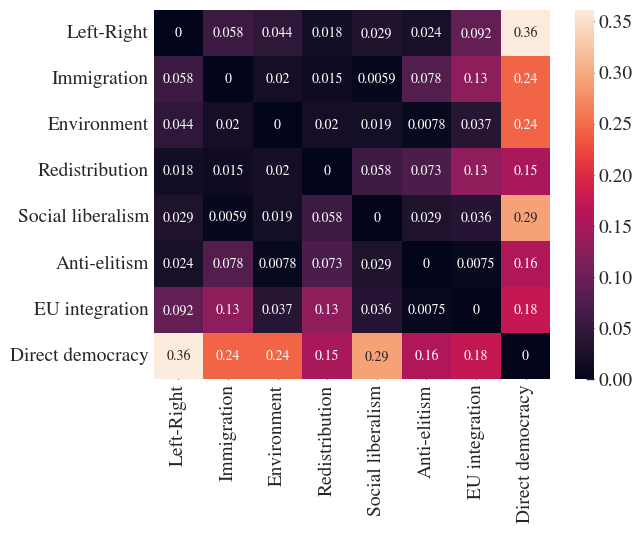

In [158]:
sns.heatmap(np.abs(df_corr['CHES'] - df_corr['X']), annot=True)

Weighted correlations by number of seats.

In [159]:
corrMat_ = ches[Dimensions_reordered].corr().values
weights = ches['seatperc'].values

for i,dim1 in enumerate(Dimensions_reordered):
    x1 = ches[dim1].values
    for j,dim2 in enumerate(Dimensions_reordered):
        if i<j:
            x2 = ches[dim2].values
            corrMat_[i,j] = corrMat_[j,i] = functions.weighted_corr(x1, x2, weights)

In [160]:
df_corr_seatperc = pd.DataFrame(index=df_corr['CHES'].index, columns=df_corr['CHES'].columns, data=corrMat_)

<Axes: >

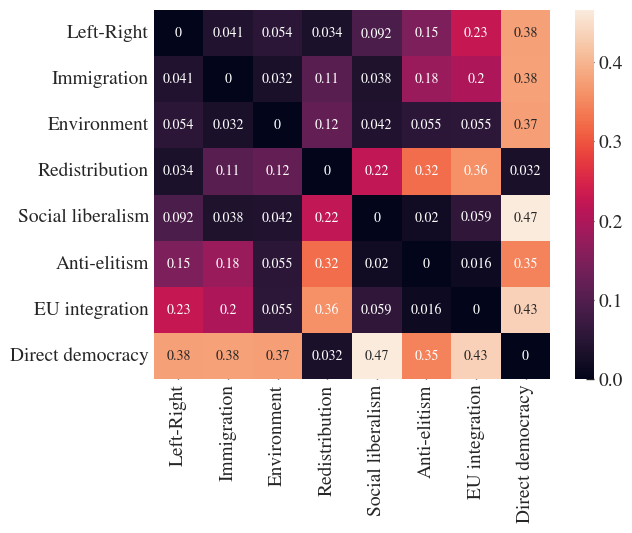

In [161]:
sns.heatmap(np.abs(df_corr_seatperc - df_corr['X']), annot=True)

In [162]:
x,y = list(), list()
for i1,d1 in enumerate(Dimensions):
    for i2,d2 in enumerate(Dimensions):
        if i1!=i2:
            x.append(df_corr_seatperc.loc[d1][d2])
            y.append(df_corr['X'].loc[d1][d2])

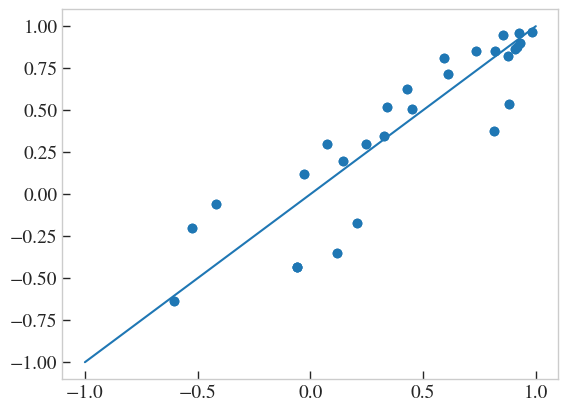

In [163]:
plt.scatter(x,y)
plt.plot([-1,1], [-1,1])

In [164]:
functions.effective_dimensionality_from_corrmat(corrMat_)

np.float64(2.4442035104142645)

Weighted correlation by number of twitter accounts

In [165]:
corrMat_ = ches[Dimensions_reordered].corr().values
weights = ches['n_twitter_accounts'].values

for i,dim1 in enumerate(Dimensions_reordered):
    x1 = ches[dim1].values
    for j,dim2 in enumerate(Dimensions_reordered):
        if i<j:
            x2 = ches[dim2].values
            corrMat_[i,j] = corrMat_[j,i] = functions.weighted_corr(x1, x2, weights)

In [166]:
df_corr_accounts = pd.DataFrame(index=df_corr['CHES'].index, columns=df_corr['CHES'].columns, data=corrMat_)

<Axes: >

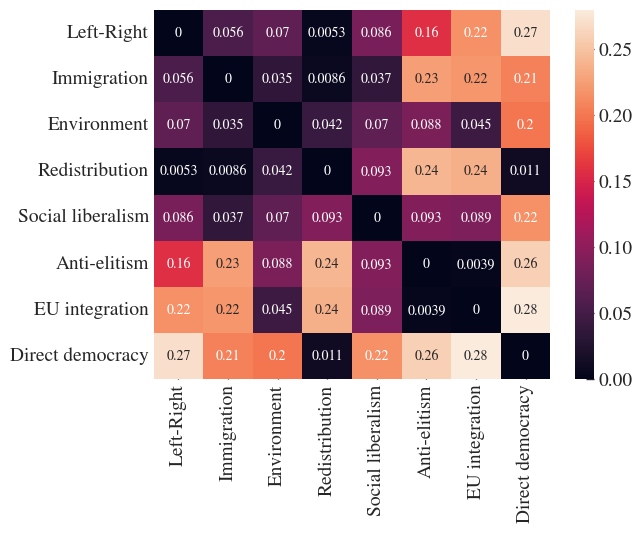

In [167]:
sns.heatmap(np.abs(df_corr_accounts - df_corr['X']), annot=True)

In [168]:
df_corr_accounts

,Left-Right,Immigration,Environment,Redistribution,Social liberalism,Anti-elitism,EU integration,Direct democracy
Left-Right,1.000,0.921,0.891,0.857,0.862,-0.038,0.085,-0.163
Immigration,0.921,1.000,0.932,0.709,0.925,0.294,0.410,0.035
Environment,0.891,0.932,1.000,0.812,0.944,0.110,0.256,-0.232
Redistribution,0.857,0.709,0.812,1.000,0.721,-0.441,-0.295,-0.624
Social liberalism,0.862,0.925,0.944,0.721,1.000,0.256,0.421,-0.132
Anti-elitism,-0.038,0.294,0.110,-0.441,0.256,1.000,0.972,0.796
EU integration,0.085,0.410,0.256,-0.295,0.421,0.972,1.000,0.659
Direct democracy,-0.163,0.035,-0.232,-0.624,-0.132,0.796,0.659,1.000


In [170]:
x,y = list(), list()
for i1,d1 in enumerate(Dimensions):
    for i2,d2 in enumerate(Dimensions):
        if i1!=i2:
            x.append(df_corr_accounts.loc[d1][d2])
            y.append(df_corr['X'].loc[d1][d2])

Text(0.5, 1.0, 'Each point is a pair of two distinct political dimensions')

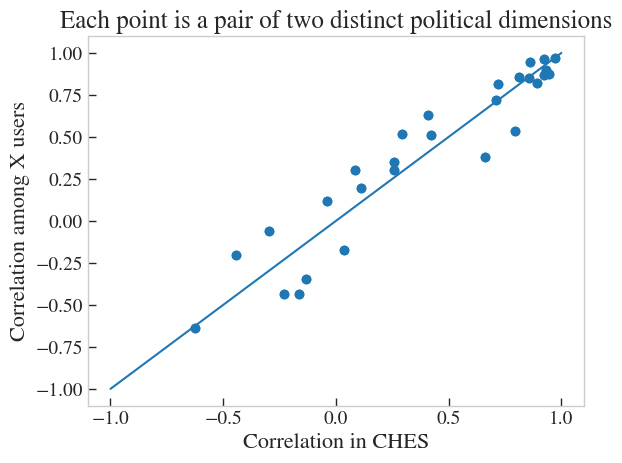

In [171]:
plt.scatter(x,y)
plt.plot([-1,1], [-1,1])
plt.xlabel('Correlation in CHES')
plt.ylabel('Correlation among X users')
plt.title('Each point is a pair of two distinct political dimensions')

In [172]:
functions.effective_dimensionality_from_corrmat(corrMat_)

np.float64(2.475614687207618)

# Perform PCA

In [173]:
pca_df, explained_variance, loadings = dict(), dict(), dict()

In [174]:
n_components = len(Dimensions)

## X panel

Standardize the data.

In [175]:
df_scaled = StandardScaler().fit_transform(df_x[Dimensions]) 

Apply PCA.

In [176]:
pca = PCA(n_components = n_components)  # Keep all components
principal_components = pca.fit_transform(df_scaled)

Create dataframe with individual coordinates along principal components.

In [177]:
columns = [f'PC{i+1}' for i in range(n_components)]

In [178]:
pca_df['X'] = pd.DataFrame(principal_components, columns=columns)

Explained variance.

In [179]:
explained_variance['X'] = pca.explained_variance_ratio_

Loadings.

In [180]:
loadings['X'] = pd.DataFrame(pca.components_.T, columns=columns, index=Dimensions)

Append PCA coordinates to X dataframe.

In [181]:
df_x.loc[:, columns] = pca_df['X'][columns]

Clean memory.

In [182]:
del df_scaled

## ESS panel

For ESS we just load the results obtained in R.

Loadings.

In [183]:
loadings['ESS'] = pd.read_csv(ess_path + 'PCA_loadings.csv')

In [184]:
# esthetic adjustments

loadings['ESS']['Variable'] = [d.replace('.', ' ') for d in loadings['ESS']['Variable'].values]
loadings['ESS']['Variable'] = loadings['ESS']['Variable'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
loadings['ESS'] = loadings['ESS'].set_index(loadings['ESS']['Variable'].values)
loadings['ESS'] = loadings['ESS'].drop(columns = 'Variable')

Explained variance.

In [185]:
explained_variance['ESS'] = pd.read_csv(ess_path + 'PCA_explained_variance.csv')

In [186]:
explained_variance['ESS'] = explained_variance['ESS']['Proportion'].values
explained_variance['ESS'] = explained_variance['ESS']/explained_variance['ESS'].sum()

Individual coordinates along principal components.

In [187]:
pca_df['ESS'] = pd.read_csv(ess_path + 'PCA_coordinates.csv')
df_ess.loc[:, columns] = pca_df['ESS'][columns].values

## CHES

In [188]:
df_scaled = StandardScaler().fit_transform(ches[Dimensions]) 

Apply PCA.

In [189]:
pca = PCA(n_components = n_components)  # Keep all components
principal_components = pca.fit_transform(df_scaled)

Create dataframe with individual coordinates along principal components.

In [190]:
columns = [f'PC{i+1}' for i in range(n_components)]

In [191]:
pca_df['CHES'] = pd.DataFrame(principal_components, columns=columns)

Explained variance.

In [192]:
explained_variance['CHES'] = pca.explained_variance_ratio_

Loadings.

In [193]:
loadings['CHES'] = pd.DataFrame(pca.components_.T, columns=columns, index=Dimensions)

Append PCA coordinates to CHES dataframe.

In [194]:
ches.loc[:, columns] = pca_df['CHES'][columns]

Clean memory.

In [195]:
del df_scaled

## Rotate and reflect PC1 and PC2

We use varimax rotation.

In [196]:
n_rotated_axes = 2
PCaxes = [f'PC{i+1}' for i in range(n_rotated_axes)]

In [197]:
rotated_loadings = dict()
rotation_matrix = dict()

for name in ('X', 'ESS', 'CHES'):
    rotated_loadings[name], rotation_matrix[name] = functions.varimax(loadings[name][PCaxes])
    rotated_loadings[name] = pd.DataFrame(rotated_loadings[name], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [198]:
df_x[[p+'_rot' for p in PCaxes]] = np.dot(df_x[Dimensions], rotated_loadings['X'])  # shape: (n_samples, n_components)
df_ess[[p+'_rot' for p in PCaxes]] = np.dot(df_ess[Dimensions], rotated_loadings['ESS'])  # shape: (n_samples, n_components)
ches[[p+'_rot' for p in PCaxes]] = np.dot(ches[Dimensions], rotated_loadings['CHES'])  # shape: (n_samples, n_components)

Reflect axes for ESS. For the X panel we just copy the rotated loadings.

In [199]:
reflected_loadings = dict()

for name in ('X', 'ESS', 'CHES'):
    reflected_loadings[name] = pd.DataFrame(rotated_loadings[name]).rename(columns={'PC1_rot': 'PC1_ref', 'PC2_rot': 'PC2_ref'})
    
values = np.array([[0,-1],[1,0]]).dot(rotated_loadings['ESS'].values.T)
reflected_loadings['ESS']['PC1_ref'] = values[0]
reflected_loadings['ESS']['PC2_ref'] = -values[1]

Add positions along the reflected axes to the dataframes.

In [200]:
df_x[[p+'_ref' for p in PCaxes]] = np.dot(df_x[Dimensions], reflected_loadings['X'])  # shape: (n_samples, n_components)
df_ess[[p+'_ref' for p in PCaxes]] = np.dot(df_ess[Dimensions], reflected_loadings['ESS'])  # shape: (n_samples, n_components)
ches[[p+'_ref' for p in PCaxes]] = np.dot(ches[Dimensions], reflected_loadings['ESS'])  # shape: (n_samples, n_components)

# Explained variance and effective dimensionality
Figure 3.

Compute effective dimensionality.

In [201]:
ED = {'ESS': functions.effective_dimensionality_from_corrmat(corrmat_ESS),
      'X': functions.effective_dimensionality_from_corrmat(df_x[Dimensions].corr().values),
      'CHES': functions.effective_dimensionality_from_corrmat(ches[Dimensions].corr().values)}

print(ED)

{'ESS': np.float64(7.2786760748487636), 'X': np.float64(2.5540042490773036), 'CHES': np.float64(2.573157425914024)}


Show explained variance.

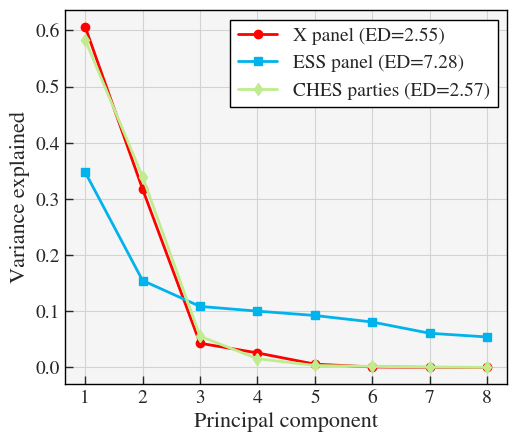

In [202]:
fig, ax = plt.subplots(figsize=(5,4.25))
ax.set_facecolor('whitesmoke')

for i,name in enumerate(('X','ESS','CHES')):
    label = DataLabel[name] + f' (ED={ED[name]:.2f})'
    plt.plot(range(n_components), explained_variance[name], lw=2, color=df_color[name], marker=Marker[name], label=label)

plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'explained_variance.png', dpi=300)
plt.show()
plt.close()

Show cumulated explained variance.

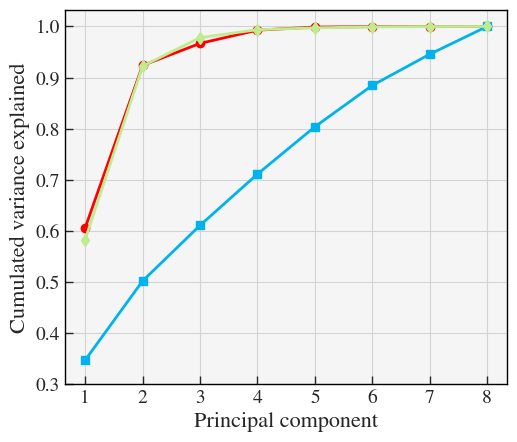

In [203]:
fig, ax = plt.subplots(figsize=(5,4.25))
ax.set_facecolor('whitesmoke')

for i,name in enumerate(('X', 'ESS', 'CHES')):
    label = DataLabel[name] + f' (ED={ED[name]:.2f})'
    plt.plot(range(n_components), explained_variance[name].cumsum(), lw=2, color=df_color[name], marker=Marker[name], label=label)

plt.xlabel('Principal component')
plt.ylabel('Cumulated variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.yticks(np.arange(3,11)/10)
plt.grid(axis='both', color='lightgrey')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'explained_variance_cumul.png', dpi=300)
plt.show()
plt.close()

# Loadings of political dimensions in the PCA space
Figure 4.

We plot the coordinates of the political dimensions in the (PC1,PC2) space, with and without labels.

X


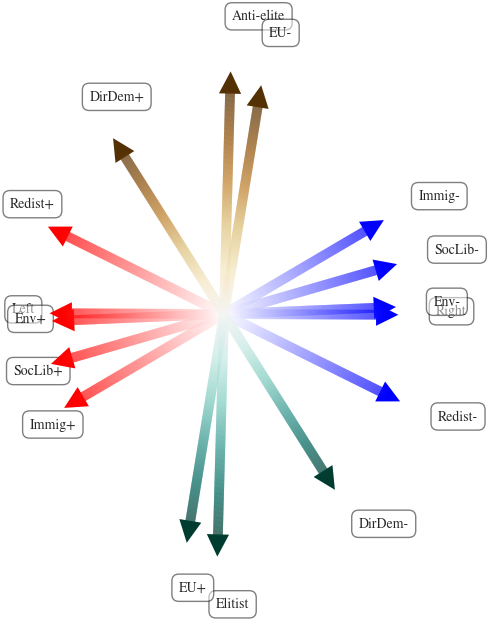

ESS


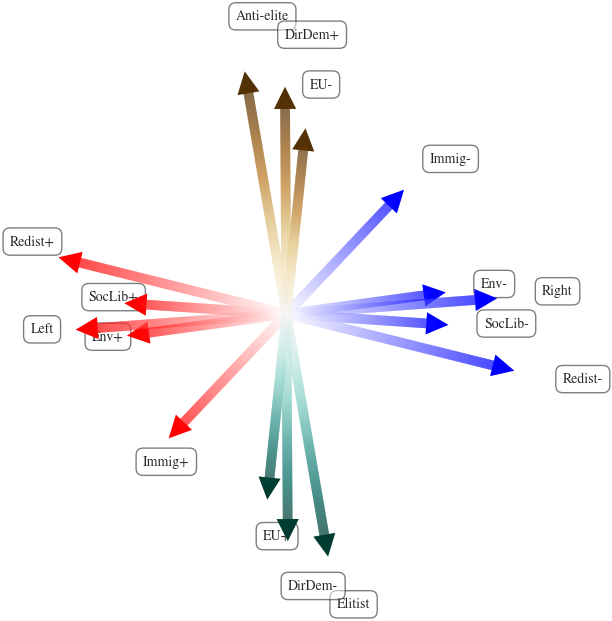

CHES


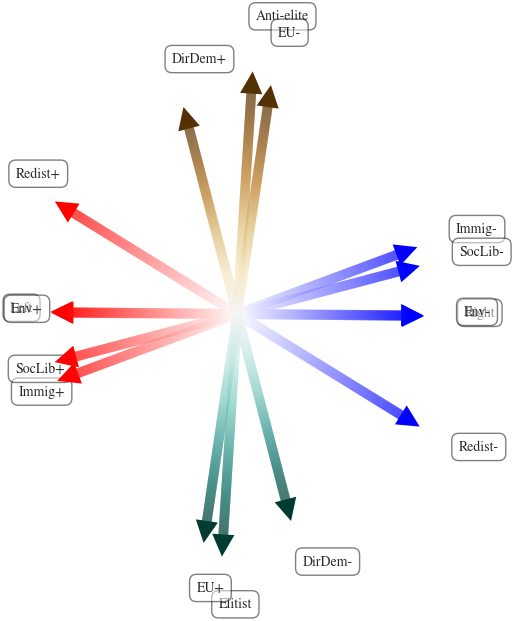

X


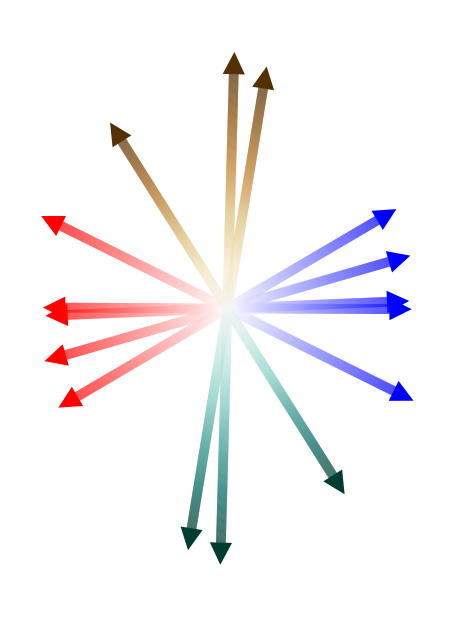

ESS


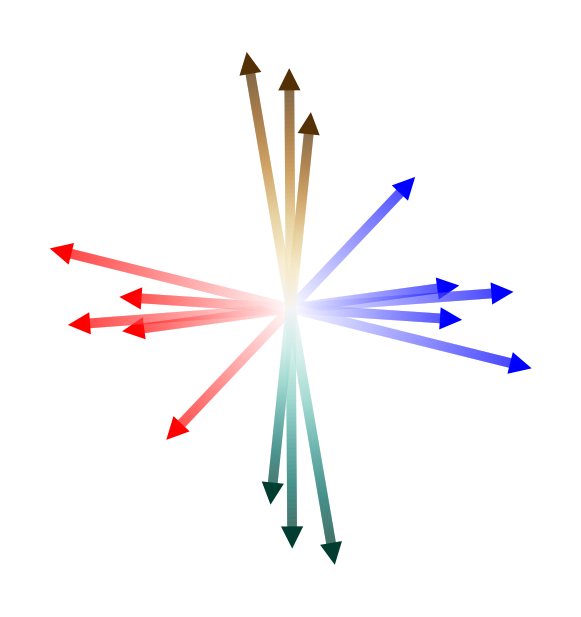

CHES


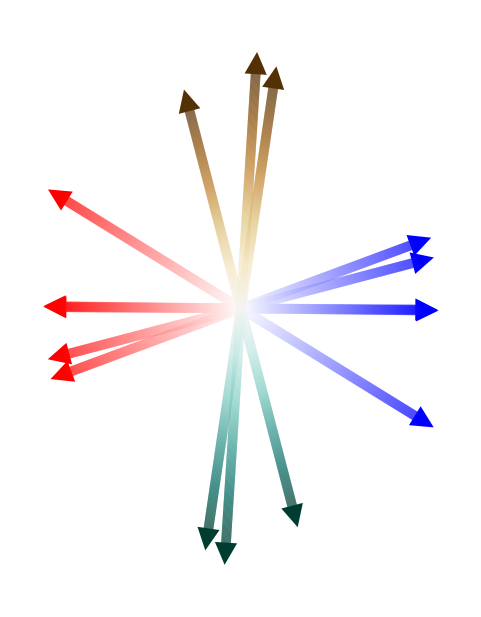

In [204]:
scale = 1.3

for text in (True,False):

    for name in ('X', 'ESS', 'CHES'):
        print(name)
        fig, ax = plt.subplots(figsize=(6,6))
        xmax, ymax = 0, 0

        for dim in Dimensions:
            x = reflected_loadings[name].loc[dim]['PC1_ref']
            y = reflected_loadings[name].loc[dim]['PC2_ref']

            if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
                cmap = 'BrBG_r'
                zorder = 10
            else:
                cmap = 'bwr_r'
                zorder = 10
            xmax = max(abs(x), abs(xmax))
            ymax = max(abs(y), abs(ymax))
            ax = functions.draw_arrow_bidim(x, y, ax, scale=1.085, center=0, cmap=cmap, zorder=zorder)

            if text:
                ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
                ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

        ax.set_xlim(-1.25*xmax, 1.25*xmax)
        ax.set_ylim(-1.25*ymax, 1.25*ymax)
        ax.set_aspect('equal')
        plt.axis('off')

        plt.tight_layout(pad=.1)

        if text:
            plt.savefig(figpath + f'sun_{name}_text.png', dpi=300)
        else:
            plt.savefig(figpath + f'sun_{name}.png', dpi=300)

        plt.show()
        plt.close()

## Weighted CHES PCA

In [205]:
ches_pca_weighted = pd.DataFrame(ches)
ches_pca_weighted = ches_pca_weighted[[c for c in ches_pca_weighted.columns if not c.startswith('PC')]]

In [206]:
ches_pca_weighted

,party,Left-Right,Social liberalism,Environment,Immigration,Direct democracy,Anti-elitism,EU integration,Redistribution,seatperc,n_twitter_accounts
0,PCF,1.125,1.625,3.857,3.250,4.125,6.500,6.667,2.000,2.080,25
1,PS,3.000,0.875,4.000,2.750,4.125,4.000,2.500,3.500,4.850,84
2,EELV,2.500,0.625,1.625,1.625,5.750,4.333,2.778,2.500,5.370,26
3,LR,7.875,7.625,7.250,7.875,2.286,4.667,4.444,8.167,10.570,172
4,RN,9.750,7.750,7.250,9.875,7.750,8.833,8.333,6.000,15.420,87
5,MoDem,6.125,4.250,6.143,5.375,3.375,2.500,0.556,6.667,8.320,52
6,RE,6.333,2.500,5.167,5.667,3.333,2.333,0.556,6.833,34.140,193
7,LFI,1.250,1.000,3.875,4.000,7.000,8.667,6.944,1.800,12.310,72
8,DLF,9.000,8.400,6.500,9.333,4.750,9.167,9.444,6.000,0.170,1


In [207]:
n_components = len(Dimensions)
weights = 'n_twitter_accounts'

loadings[weights], pca_df[weights], explained_variance[weights] = functions.weightedPCA(ches_pca_weighted, Dimensions, weights, n_components)

# append to existing df
columns = [f'PC{i+1}' for i in range(n_components)]
ches_pca_weighted.loc[:, columns] = pca_df[weights][columns]

In [208]:
n_rotated_axes = 2
PCaxes = [f'PC{i+1}' for i in range(n_rotated_axes)]

In [209]:
rotated_loadings[weights], rotation_matrix[weights] = functions.varimax(loadings[weights][PCaxes])
rotated_loadings[weights] = pd.DataFrame(rotated_loadings[weights], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [210]:
reflected_loadings[weights] = pd.DataFrame(rotated_loadings[weights])
reflected_loadings[weights] = reflected_loadings[weights].rename(columns={'PC1_rot':'PC1_ref', 'PC2_rot':'PC2_ref'})
reflected_loadings[weights]['PC1_ref'] = -reflected_loadings[weights]['PC1_ref']

In [211]:
ches_pca_weighted[[p+'_ref' for p in PCaxes]] = np.dot(ches_pca_weighted[Dimensions], reflected_loadings[weights])  # shape: (n_samples, n_components)

In [212]:
ches_pca_weighted

,party,Left-Right,Social liberalism,Environment,Immigration,Direct democracy,Anti-elitism,EU integration,Redistribution,seatperc,...,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC1_ref,PC2_ref
0,PCF,1.125,1.625,3.857,3.250,4.125,6.500,6.667,2.000,2.080,...,5.861,4.808,2.700,0.086,-0.524,-0.582,0.416,-0.003,4.755,9.701
1,PS,3.000,0.875,4.000,2.750,4.125,4.000,2.500,3.500,4.850,...,6.158,-0.040,0.331,-0.378,0.125,-0.442,-0.174,0.006,5.454,4.895
2,EELV,2.500,0.625,1.625,1.625,5.750,4.333,2.778,2.500,5.370,...,8.028,1.433,-0.612,-2.022,-0.571,0.678,0.052,0.004,3.323,5.955
3,LR,7.875,7.625,7.250,7.875,2.286,4.667,4.444,8.167,10.570,...,-5.300,-1.345,1.776,-0.040,-0.064,0.096,-0.038,0.005,16.938,5.958
4,RN,9.750,7.750,7.250,9.875,7.750,8.833,8.333,6.000,15.420,...,-7.552,6.058,-2.043,-0.237,-0.007,-0.166,0.016,0.005,17.630,13.664
5,MoDem,6.125,4.250,6.143,5.375,3.375,2.500,0.556,6.667,8.320,...,0.435,-3.882,-0.289,-0.366,1.136,0.049,0.148,-0.018,11.841,2.303
6,RE,6.333,2.500,5.167,5.667,3.333,2.333,0.556,6.833,34.140,...,1.414,-4.070,-1.153,0.383,-0.237,0.025,0.019,-0.000,10.922,1.918
7,LFI,1.250,1.000,3.875,4.000,7.000,8.667,6.944,1.800,12.310,...,5.668,7.385,0.408,0.768,0.236,0.345,-0.042,-0.001,4.417,12.264
8,DLF,9.000,8.400,6.500,9.333,4.750,9.167,9.444,6.000,0.170,...,-7.437,5.915,1.027,-0.385,-1.416,-0.257,-0.360,-0.750,17.546,13.501


([<matplotlib.axis.XTick at 0x72bd543687d0>,
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8')])

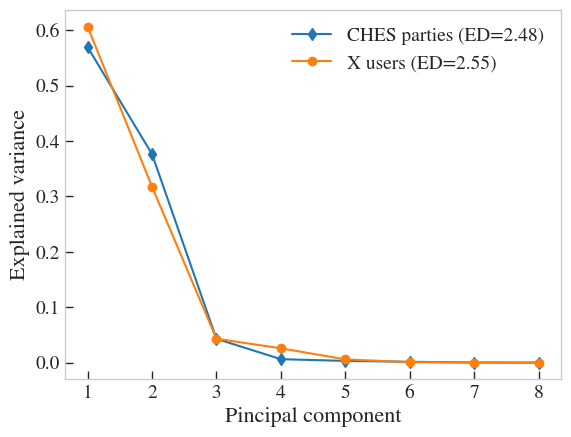

In [218]:
plt.plot(explained_variance['n_twitter_accounts'], marker='d', label='CHES parties (ED=2.48)')
plt.plot(explained_variance['X'], marker='o', label='X users (ED=2.55)')
plt.legend(loc='best')
plt.xlabel('Pincipal component')
plt.ylabel('Explained variance')
plt.xticks(range(8), range(1,9))

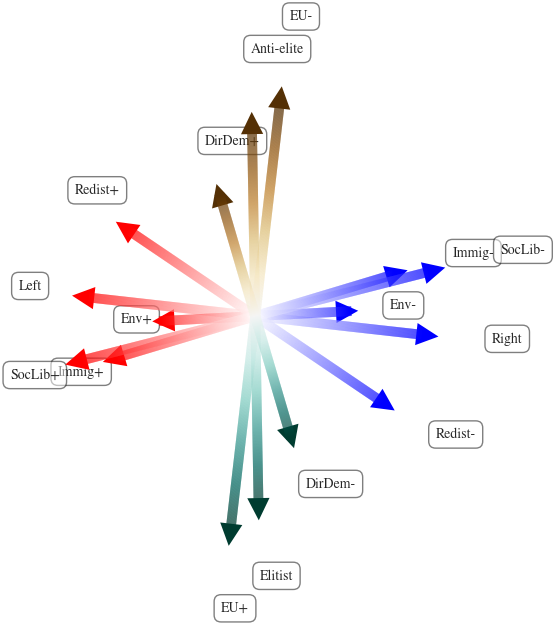

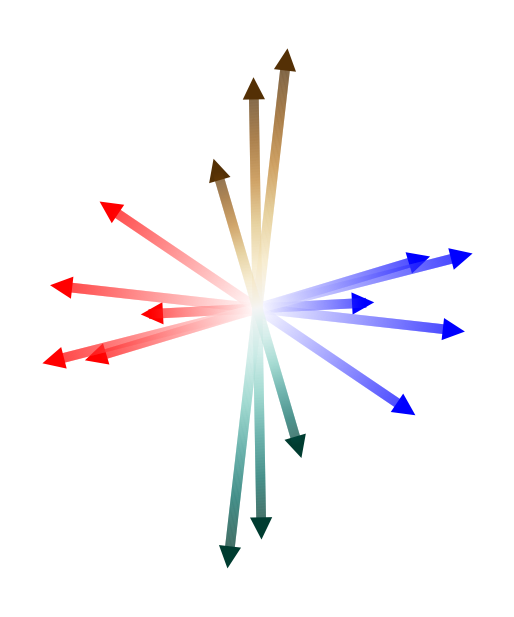

In [310]:
scale = 1.4
normalize = False

name = 'n_twitter_accounts'

for text in (True,False):

    fig, ax = plt.subplots(figsize=(6,6))
    xmax, ymax = 0, 0
    if normalize:
        max1 = reflected_loadings[name]['PC1_ref'].abs().max()
        max2 = reflected_loadings[name]['PC2_ref'].abs().max()

    for dim in Dimensions:
        x = reflected_loadings[name].loc[dim]['PC1_ref']
        y = reflected_loadings[name].loc[dim]['PC2_ref']
        if normalize:
            x = x / max1
            y = y / max2
        if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
            cmap = 'BrBG_r'
            zorder = 10
        else:
            cmap = 'bwr_r'
            zorder = 10
        xmax = max(abs(x), abs(xmax))
        ymax = max(abs(y), abs(ymax))
        ax = functions.draw_arrow_bidim(x, y, ax, center=0, cmap=cmap, zorder=zorder, scale=1.1)
        if text:
            ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
            ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

    # ax.plot([-1.25,1.25], [0,0], ls='--', color='lightgrey', zorder=-10000)
    # ax.plot([0,0], [-1.25,1.25], ls='--', color='lightgrey', zorder=-10000)
    ax.set_xlim(-1.25*xmax, 1.25*xmax)
    ax.set_ylim(-1.25*ymax, 1.25*ymax)
    ax.set_aspect('equal')
    plt.axis('off')
    plt.tight_layout(pad=.1)
    if text:
        plt.savefig(figpath + f'sun_text.png', dpi=300)
    else:
        plt.savefig(figpath + f'sun.png', dpi=300)
    plt.show()
    plt.close()

# 3D distributions of panelists in PCA space
Figure 5.

First we plot for X panel.

/tmp/ipykernel_2241382/3822370053.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/3822370053.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


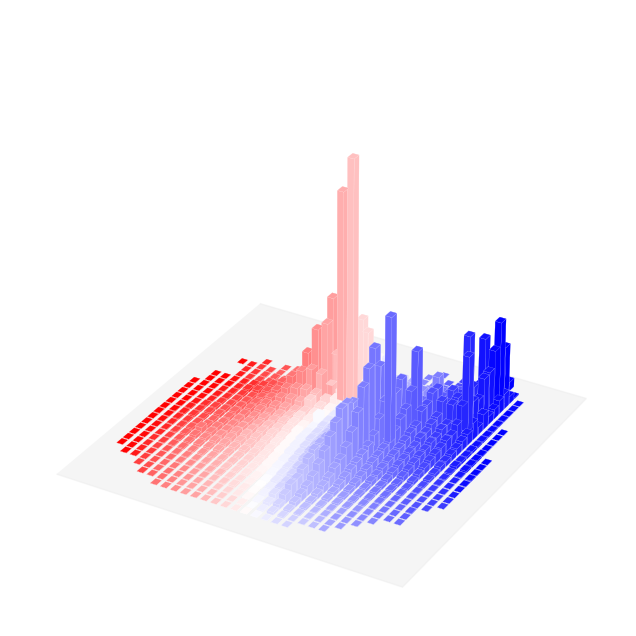

/tmp/ipykernel_2241382/3822370053.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/3822370053.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


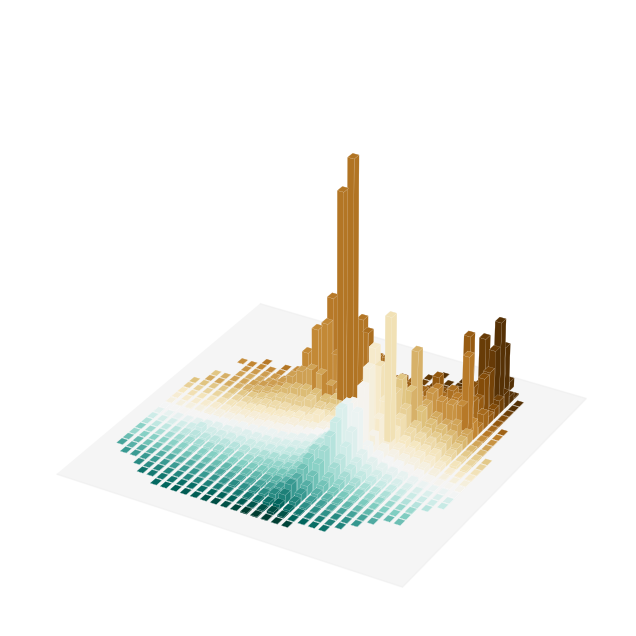

In [ ]:
for dim in ('Left-Right','Anti-elitism'):
    
    # ensure df_tmp is a DataFrame
    df_tmp = pd.DataFrame(df_x)
    n_bins = 30

    # bin PCs
    df_tmp['PC1_bin'] = pd.cut(df_tmp['PC1_ref'], bins=n_bins)
    df_tmp['PC2_bin'] = pd.cut(df_tmp['PC2_ref'], bins=n_bins)

    # bin centers
    df_tmp['PC1_center'] = df_tmp['PC1_bin'].apply(lambda b: round((b.left + b.right)/2, 2))
    df_tmp['PC2_center'] = df_tmp['PC2_bin'].apply(lambda b: round((b.left + b.right)/2, 2))

    # aggregate mean(dim) and count
    agg_df = (
        df_tmp
        .groupby(['PC1_center', 'PC2_center'])
        .agg(mean_dim=(dim, 'mean'), count=('PC1', 'size'))
        .reset_index()
    )

    # remove empty bins
    agg_df = agg_df[agg_df['count'] > 0].copy()

    # create grid
    X = agg_df['PC1_center'].values
    Y = agg_df['PC2_center'].values
    Z = np.zeros_like(X)
    dz = agg_df['count'].values

    # choose colormap based on your existing rule
    cmap = 'BrBG_r' if dim in ('Anti-elitism', 'EU integration', 'Direct democracy') else 'bwr_r'

    # normalize dim values to [0,1] for color mapping
    norm = plt.Normalize(agg_df['mean_dim'].min(), agg_df['mean_dim'].max())
    colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))

    # bar width
    dx = dy = (df_tmp['PC1'].max() - df_tmp['PC1'].min()) / n_bins

    # plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    ax.bar3d(X, Y, Z, dx, dy, dz, color=colors, edgecolor='w', linewidth=.1, shade=False, alpha=1)

    ax.tick_params(size=0)

    # remove 3D grid, background panes and axis lines
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent


    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.savefig(figpath + f'3D_x_{dim}.png', transparent=True, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

Now for ESS panel.

/tmp/ipykernel_2241382/1721636004.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/1721636004.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


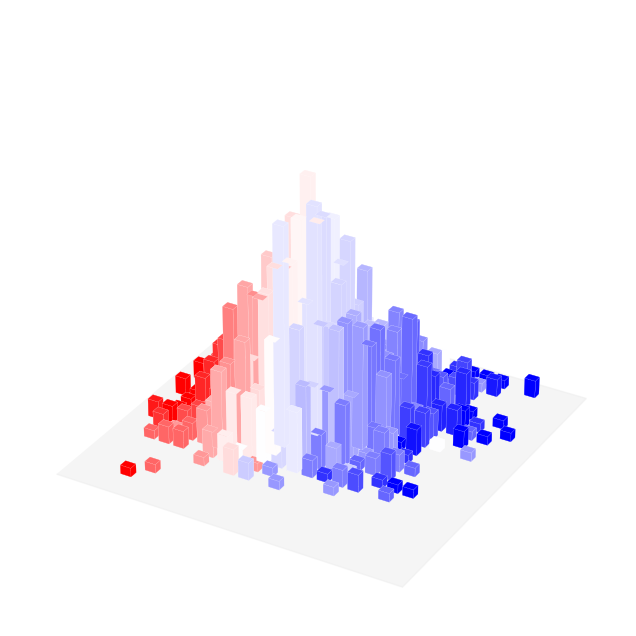

/tmp/ipykernel_2241382/1721636004.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/1721636004.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


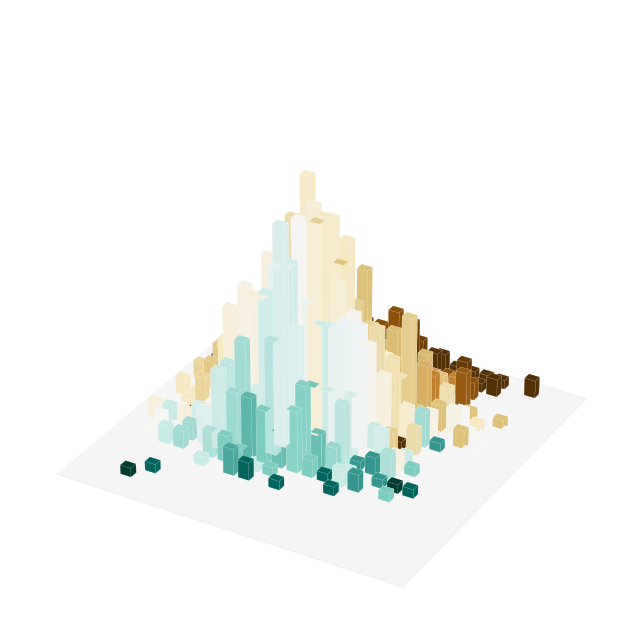

In [ ]:
for dim in ('Left-Right','Anti-elitism'):
    
    # ensure df_tmp is a DataFrame
    df_tmp = pd.DataFrame(df_ess)
    n_bins = 20

    # bin PCs
    df_tmp['PC1_bin'] = pd.cut(df_tmp['PC1_ref'], bins=n_bins)
    df_tmp['PC2_bin'] = pd.cut(df_tmp['PC2_ref'], bins=n_bins)

    # bin centers
    df_tmp['PC1_center'] = df_tmp['PC1_bin'].apply(lambda b: round((b.left + b.right)/2, 2))
    df_tmp['PC2_center'] = df_tmp['PC2_bin'].apply(lambda b: round((b.left + b.right)/2, 2))

    # aggregate mean(dim) and count
    agg_df = (
        df_tmp
        .groupby(['PC1_center', 'PC2_center'])
        .agg(mean_dim=(dim, 'mean'), count=('PC1', 'size'))
        .reset_index()
    )

    # remove empty bins
    agg_df = agg_df[agg_df['count'] > 0].copy()

    # create grid
    X = agg_df['PC1_center'].values
    Y = agg_df['PC2_center'].values
    Z = np.zeros_like(X)
    dz = agg_df['count'].values

    # choose colormap based on your existing rule
    cmap = 'BrBG_r' if dim in ('Anti-elitism', 'EU integration', 'Direct democracy') else 'bwr_r'

    # normalize dim values to [0,1] for color mapping
    norm = plt.Normalize(agg_df['mean_dim'].min(), agg_df['mean_dim'].max())
    colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))

    # bar width
    dx = dy = (df_tmp['PC1'].max() - df_tmp['PC1'].min()) / n_bins

    # plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    ax.bar3d(X, Y, Z, dx, dy, dz, color=colors, edgecolor='w', linewidth=.1, shade=False, alpha=1)

    ax.tick_params(size=0)

    # remove 3D grid, background panes and axis lines
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent


    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.savefig(figpath + f'3D_ess_{dim}.png', transparent=True, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

# Variations with activity and popularity
Figure 6.

In [ ]:
figsize = (5,4) # for plots

In [ ]:
Metrics = ('activity', 'popularity')

Set up bins and bin labels for each metric.

In [ ]:
bins, ticklabels, bin_labels = dict(), dict(), dict()

bins['activity'] = [-np.inf, 0, .01, .1, 1, 10, 100, np.inf]
ticklabels['activity'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{0.01}$',
        '$\\mathdefault{0.01}$-$\\mathdefault{0.1}$',
        '$\\mathdefault{0.1}$-$\\mathdefault{1}$',
        '$\\mathdefault{1}$-$\\mathdefault{10}$',
        '$\\mathdefault{10}$-$\\mathdefault{100}$',
        '>$\\mathdefault{100}$',
        ]
bin_labels['activity'] = [f"({bins['activity'][i]}, {bins['activity'][i+1]})" for i in range(len(bins['activity'])-1)]
    
bins['popularity'] = [-np.inf, 0, 10, 100, 1000, 10000, 100000, np.inf]
ticklabels['popularity'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{10^1}$',
        '$\\mathdefault{10^1}$-$\\mathdefault{10^2}$',
        '$\\mathdefault{10^2}$-$\\mathdefault{10^3}$',
        '$\\mathdefault{10^3}$-$\\mathdefault{10^4}$',
        '$\\mathdefault{10^4}$-$\\mathdefault{10^5}$',
        '>$\\mathdefault{10^5}$',
        ]
bin_labels['popularity'] = [f"({bins['popularity'][i]}, {bins['popularity'][i+1]})" for i in range(len(bins['popularity'])-1)]

Sort users into bins by activity and by popularity.

In [ ]:
df_x['activity_bin'] = pd.cut(df_x['mean_tweets_per_day'], bins=bins['activity'], labels=bin_labels['activity'])
df_x['popularity_bin'] = pd.cut(df_x['followers'], bins=bins['popularity'], labels=bin_labels['popularity'])

Plot effective dimensionality, depending on activity or popularity.

/tmp/ipykernel_2241382/3534221472.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels['activity'])
/tmp/ipykernel_2241382/3534221472.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(ticklabels['popularity'])


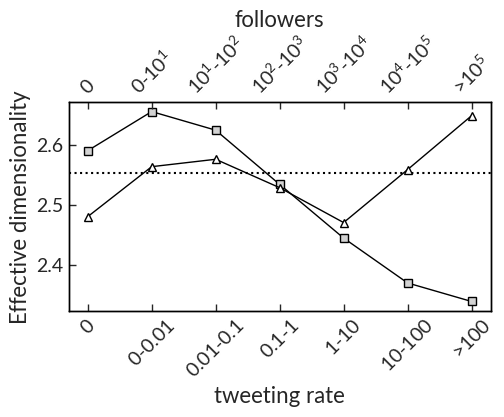

In [ ]:
fig,ax = plt.subplots(figsize=figsize)

# value with all users
ax.axhline(functions.effective_dimensionality(df_x, Dimensions), color='k', ls=':', label='All users')

# for activity
effective_dim = [functions.effective_dimensionality(df_x[df_x['activity_bin']==bl], Dimensions) for bl in bin_labels['activity']]
ax.plot(bin_labels['activity'], effective_dim, color='k', lw=1, marker='s', markerfacecolor='lightgrey', label=f'tweeting rate', zorder=100)
ax.set_xticklabels(ticklabels['activity'])
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('tweeting rate')
ax.set_ylabel(r'Effective dimensionality')

# for popularity
ax_ = ax.twiny()
effective_dim = [functions.effective_dimensionality(df_x[df_x['popularity_bin']==bl], Dimensions) for bl in bin_labels['popularity']]
ax_.plot(bin_labels['popularity'], effective_dim, color='k', lw=1, marker='^', markerfacecolor='w', label=f'followers', zorder=10)
ax_.set_xlabel('followers')
ax_.tick_params(axis='x', rotation=45)
ax_.set_xticklabels(ticklabels['popularity'])

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
    ax_.spines[pos].set_visible(True)
    ax_.spines[pos].set_color('k')
    ax_.spines[pos].set_linewidth(1)
ax.tick_params(length=5, direction='in')
ax_.tick_params(length=5, direction='in')

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + 'actipop_ED.png', dpi=300)
plt.show()
plt.close()

Distribution of positions for a chosen dimension (e.g., EU integration).

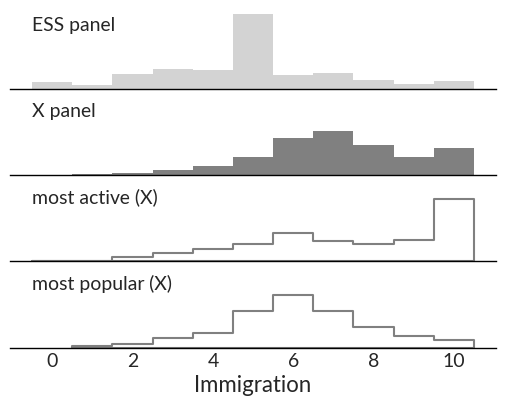

In [ ]:
dim = 'Immigration'

names_ = ('ESS panel', 'X panel', 'most active (X)', 'most popular (X)')

n_bins = len(ess_label_range[dim])

fig, axes = plt.subplots(4, 1, figsize=(5,4), sharey=True, sharex=True)

# ESS
sns.histplot(data=functions.get_ess_counts(ess_counts_full, dim), x='bin', weights='count', bins=n_bins, color='lightgrey', edgecolor='none', alpha=1, discrete=True, ax=axes[0])

# X
sns.histplot(data=functions.get_x_counts(df_x, dim), x='bin', weights='count', bins=n_bins, color='grey', edgecolor='none',alpha=1,discrete=True, ax=axes[1])

# X (most active)
sns.histplot(data=functions.get_x_counts(df_x[df_x['activity_bin']=='(100, inf)'], dim), x='bin', weights='count', element='step',bins=n_bins,color='none', alpha=1, lw=1.5, edgecolor='grey', discrete=True, fill=True, ax=axes[2])

# X (most popular)
sns.histplot(data=functions.get_x_counts(df_x[df_x['popularity_bin']=='(100000, inf)'], dim), x='bin', weights='count',element='step', bins=n_bins, color='none', alpha=1, lw=1.5, edgecolor='grey', discrete=True, fill=True, ax=axes[3])

# esthetics
for k in range(4):
    axes[k].set_ylabel('')
    xlabel = dim if k==3 else ''
    axes[k].set_xlabel(xlabel)
    axes[k].tick_params(axis='x', length=0)
    axes[k].text(x=-.5, y=.3, s=names_[k], fontsize=14)
    axes[k].yaxis.set_visible(False)

    for pos in ( 'bottom', ):
        axes[k].spines[pos].set_visible(True)
        axes[k].spines[pos].set_color('k')
        axes[k].spines[pos].set_linewidth(1)
    for pos in ( 'top', 'left', 'right'):
        axes[k].spines[pos].set_visible(False)

plt.tight_layout(pad=.5)
plt.savefig(figpath + f'actipop_{dim}_hist.png', dpi=300)
plt.show()
plt.close()

Average positions of users along PC1 and PC2, depending on activity or popularity.

/tmp/ipykernel_2241382/1748545564.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2241382/1748545564.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


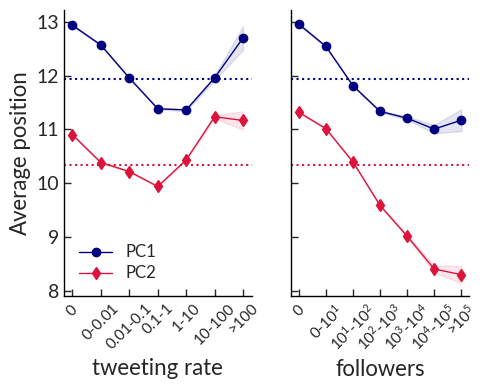

In [ ]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
color = {'PC1_ref':'navy', 'PC2_ref':'crimson'}
marker = {'PC1_ref':'o', 'PC2_ref':'d'}
label_ = {'PC1_ref':'PC1', 'PC2_ref':'PC2'}

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    #ax.axhline(effective_dim_base, color='k', ls=':', label='All users')
    for PCdim in ('PC1_ref','PC2_ref'):
        ax.axhline(y=df_x[PCdim].mean(), color=color[PCdim], ls=':', zorder=-100)# label=PCdim[:-4]+' (all users)')

        PC_avg = [df_x[df_x[metric+'_bin']==bl][PCdim].mean() for bl in bin_labels[metric]]
        ax.plot(bin_labels[metric], PC_avg, color=color[PCdim], lw=1, marker=marker[PCdim], label=label_[PCdim])

        ci_lower, ci_upper = list(), list()
        for bl in bin_labels[metric]:
            mean = df_x[df_x[metric+'_bin']==bl][PCdim].mean()
            sem = stats.sem(df_x[df_x[metric+'_bin']==bl][PCdim].values)
            ci_lower.append(mean - z*sem)
            ci_upper.append(mean + z*sem)
        ax.fill_between(bin_labels[metric], ci_lower, ci_upper, color=color[PCdim], alpha=.1, zorder=-10)

    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = 'Average position' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # axe lines
    for pos in ('bottom', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)

    ax.tick_params(length=5, direction='in')

    if i==0:
        ax.legend(loc='best', ncols=1, frameon=False, framealpha=1, labelspacing=.3, shadow=True, fontsize=12)

plt.tight_layout(w_pad=2)
plt.savefig(figpath + f'actipop_PC12.png', dpi=300)
plt.show()
plt.close()

Average correlation between positions on PCs.

/tmp/ipykernel_2236545/3689649594.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2236545/3689649594.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


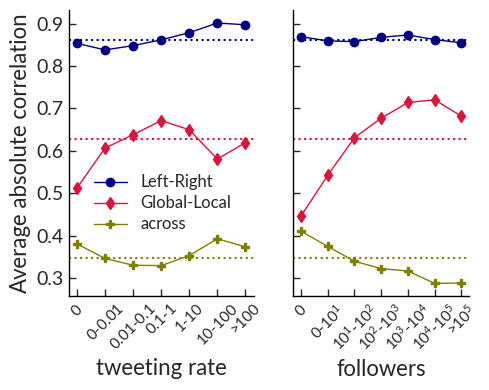

In [ ]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    # left-right
    baseline = df_x[Dimensions].corr().abs().values[:5,:5][np.triu_indices(5,1)].mean()
    corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[:5,:5][np.triu_indices(5,1)].mean() for bl in bin_labels[metric]]
    ax.axhline(y=baseline, color='navy', ls=':', zorder=-100)#, label='Left-Right (all users)')
    ax.plot(bin_labels[metric], corr, color='navy', lw=1, marker='o', label='Left-Right')

    # global-local
    baseline = df_x[Dimensions].corr().abs().values[-3:,-3:][np.triu_indices(3,1)].mean()
    corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[-3:,-3:][np.triu_indices(3,1)].mean() for bl in bin_labels[metric]]
    ax.axhline(y=baseline, color='crimson', ls=':', zorder=-100)#, label='Global-Local (all users)')
    ax.plot(bin_labels[metric], corr, color='crimson', lw=1, marker='d', label='Global-Local')

    # across
    baseline = df_x[Dimensions].corr().abs().values[:5,-3:].mean()
    corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[:5,-3:].mean() for bl in bin_labels[metric]]
    ax.axhline(y=baseline, color='olive', ls=':', zorder=-100)#, label='across (all users)')
    ax.plot(bin_labels[metric], corr, color='olive', lw=1, marker='P', label='across')

    # esthetics
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = 'Average absolute correlation' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    for pos in ('bottom', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)

    ax.tick_params(length=5, direction='in')

    if i==0:
        ax.legend(loc=(.1,.2), ncols=1, frameon=False, labelspacing=.3, shadow=False, fontsize=12)


plt.tight_layout(w_pad=2)
plt.savefig(figpath + f'actipop_corr.png', dpi=300)
plt.show()
plt.close()

Polarization and Wasserstein distance (WD) across activity and popularity bins.

In [ ]:
pola = {m: {dim: list() for dim in Dimensions} for m in('activity','popularity')}
WD = {m: {dim: list() for dim in Dimensions} for m in ('activity','popularity')}

for m in ('activity','popularity'):

    for bl in bin_labels[m]:
        df_tmp = df_x[df_x[m+'_bin']==bl]

        # pola and WD
        for dim in Dimensions:
            x_counts = functions.get_x_counts(df_tmp, dim)
            pola[m][dim].append(functions.polarization_from_counts_df(x_counts))

            # WD 
            ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')
            x_counts = functions.get_x_counts(df_tmp, dim).sort_values(by='bin')
            mini = np.min(ess_label_range[dim])
            maxi = np.max(ess_label_range[dim])
            wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
            wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
            wd = wd / wd_max
            WD[m][dim].append(wd)

Get baselines, computed on the whole dataset.

In [ ]:
pola_baseline = dict()
wd_baseline = dict()

for dim in Dimensions:
    x_counts = functions.get_x_counts(df_x, dim)
    pola_baseline[dim] = functions.polarization_from_counts_df(x_counts)

    # WD 
    ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')
    x_counts = functions.get_x_counts(df_x, dim).sort_values(by='bin')
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
    wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
    wd = wd / wd_max
    wd_baseline[dim] = wd

Plot polarization.

/tmp/ipykernel_2236545/3801262146.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2236545/3801262146.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


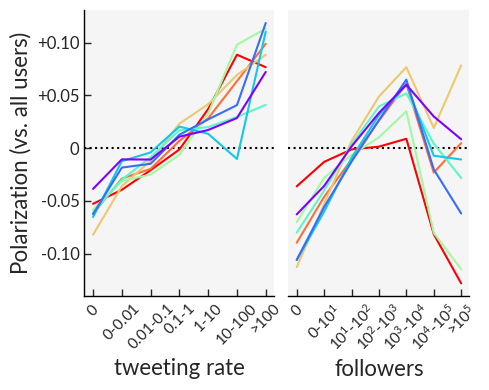

In [ ]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
marker = {'activity':'s', 'popularity':'^'}
cmap = plt.get_cmap('rainbow_r')

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    # plot
    ax.axhline(y=0, ls=':', color='k',  lw=1.5)
    for j,dim in enumerate(Dimensions):
        c = cmap(j/(len(Dimensions)-1))
        diff = np.array(pola[metric][dim]-pola_baseline[dim])
        ax.plot(bin_labels[metric], diff, label=dim, color=c, lw=1.5)

    # esthetics
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = 'Polarization (vs. all users)' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(length=5, direction='in')

    for pos in ('bottom', 'top', 'right', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)
    if i==1:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)
    ax.set_facecolor('whitesmoke')

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:+.2f}" if y!=0 else "0"))

plt.tight_layout(w_pad=.2)
plt.savefig(figpath + f'actipop_pola.png', dpi=300)
plt.show()
plt.close()

Plot Wasserstein distance.

/tmp/ipykernel_2236545/1720713530.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2236545/1720713530.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


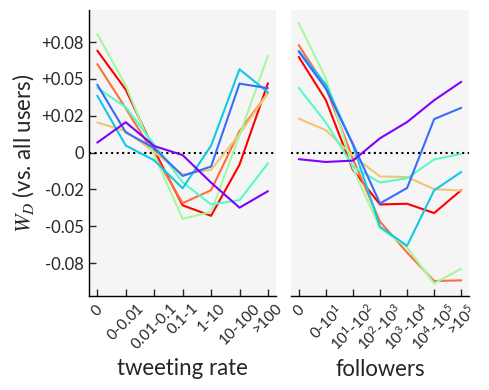

In [ ]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
marker = {'activity':'s', 'popularity':'^'}
cmap = plt.get_cmap('rainbow_r')

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    ax.axhline(y=0, ls=':', color='k',  lw=1.5)
    for j,dim in enumerate(Dimensions):
        c = cmap(j/(len(Dimensions)-1))
        diff = np.array(WD[metric][dim]-wd_baseline[dim])
        ax.plot(bin_labels[metric], diff, label=dim, color=c, lw=1.5)

    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = r'$W_D$ (vs. all users)' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(length=5, direction='in')

    # axe lines
    for pos in ('bottom', 'top', 'right', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)
    if i==1:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)
    ax.set_facecolor('whitesmoke')

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:+.2f}" if y!=0 else "0"))

plt.tight_layout(w_pad=.2)
plt.savefig(figpath + f'actipop_wd.png', dpi=300)
plt.show()
plt.close()

# Analysis of X panel weighted by users' visibility
Figure 7.

In [ ]:
Marker['Visibility'] = '^'
DataLabel['Visibility'] = 'X panel (weighted)'
df_color['Visibility'] = 'limegreen'
name_vis = 'Visibility'

In [ ]:
df_x['visibility'] = df_x['mean_tweets_per_day'] * df_x['followers']

In [ ]:
df_visibility = df_x[~df_x['visibility'].isna()]

## Analyze

We use the `weighted=True` parameter of our custom function `functions.get_x_counts`, which takes into accounts individual weights to return user counts within bins.

Dimension-wise distributions.

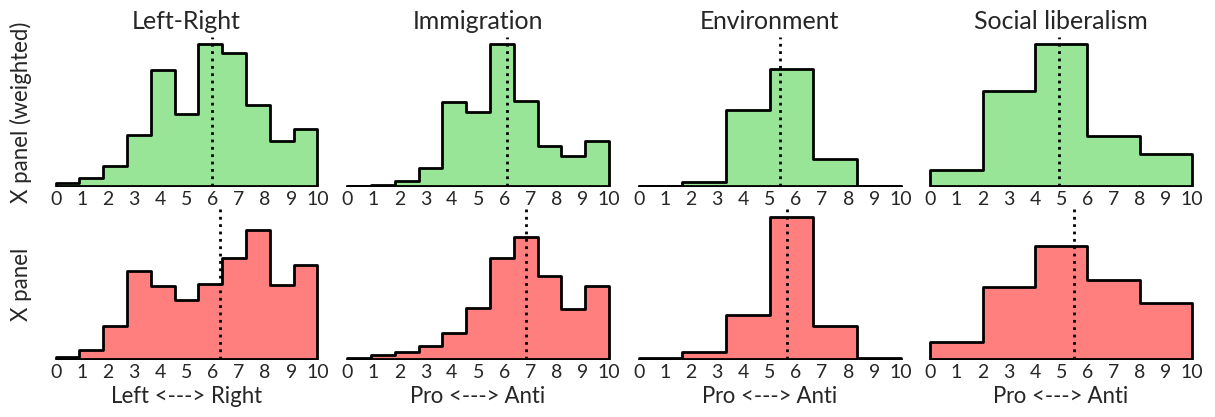

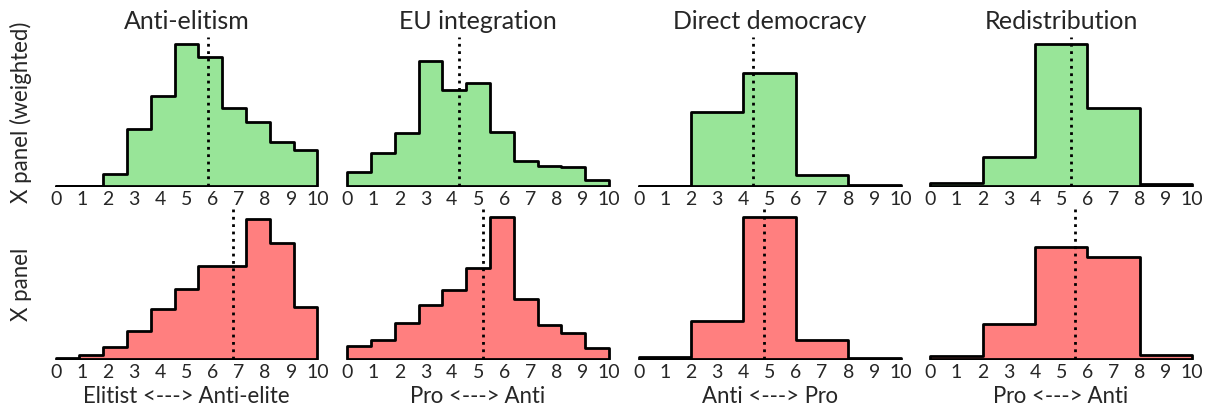

In [ ]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Count bin occurrences, weighted and non-weighted
        Counts['Visibility'] = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility')
        Counts['X'] = functions.get_x_counts(df_x, dim, weighted=False)

        # compute WS
        mini = np.min(ess_label_range[dim])
        maxi = np.max(ess_label_range[dim])
        ws_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
        ws = stats.wasserstein_distance(Counts['Visibility']['bin'], Counts['X']['bin'], Counts['Visibility']['count'], Counts['X']['count'])
        ws = ws / ws_max

        for j,label in enumerate(('Visibility', 'X')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot hist
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label],  edgecolor='none', discrete=True, alpha=.5, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', discrete=True, alpha=.5, ax=ax)

            # esthetics
            if label=='Visibility':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            if j==1:
                ax.set_xticks(xticks1, xticks2)
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    # save
    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'visibility_histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

Polarization.

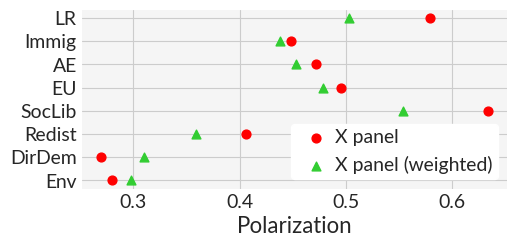

In [ ]:
Dimensions_ordered = ['Environment', 'Direct democracy', 'Redistribution', 'Social liberalism', 'EU integration', 'Anti-elitism', 'Immigration', 'Left-Right']

# Combine all data into one list
data_x = {'Dimension':list(), 'Polarization':list()}
data_visibility = {'Dimension':list(), 'Polarization':list()}

for dim in Dimensions_ordered:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_visibility, dim, weighted=False)
    visibility_counts = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility')
    
    # compute pola
    pola_x = functions.polarization_from_counts_df(x_counts)
    pola_visibility = functions.polarization_from_counts_df(visibility_counts)

    # append
    data_x['Dimension'].append(dim)
    data_visibility['Dimension'].append(dim)
    data_x['Polarization'].append(pola_x)
    data_visibility['Polarization'].append(pola_visibility)

# create dfs
data_x = pd.DataFrame(data_x)
data_visibility = pd.DataFrame(data_visibility)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(5,2.3))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Polarization'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], s=40, label=DataLabel['X'])
plt.scatter(data_visibility['Polarization'], data_visibility['Dimension'], color=df_color['Visibility'], marker=Marker['Visibility'], s=40, label='X panel (weighted)')

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
ax.tick_params(length=0)

plt.legend(frameon=True, framealpha=1, loc='lower right', edgecolor='w', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Polarization')
plt.yticks(range(xaxis.size), [short_label[d] for d in data_x['Dimension'].values])

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'visibility_polarization.png', dpi=300)
plt.show()
plt.close()

Wasserstein distance with ESS panel.

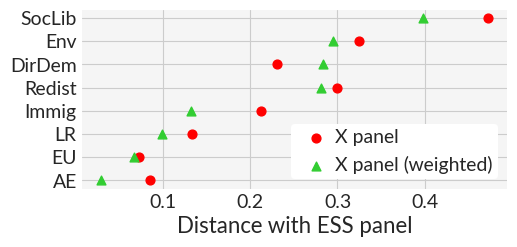

In [ ]:
# Combine all data into one list
data_x = {'Dimension':list(), 'Distance':list()}
data_visibility = {'Dimension':list(), 'Distance':list()}

for dim in Dimensions:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_visibility, dim, weighted=False).sort_values(by='bin')
    visibility_counts = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility').sort_values(by='bin')
    ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')

    # compute theoretical max distance
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])

    # compute wd
    wd_x = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count']) / wd_max
    wd_visibility = stats.wasserstein_distance(visibility_counts['bin'], ess_counts['bin'], visibility_counts['count'], ess_counts['count']) / wd_max

    # append
    data_x['Dimension'].append(dim)
    data_visibility['Dimension'].append(dim)
    data_x['Distance'].append(wd_x)
    data_visibility['Distance'].append(wd_visibility)

# create dfs
data_x = pd.DataFrame(data_x)
data_visibility = pd.DataFrame(data_visibility)

# sort
data_visibility = data_visibility.sort_values(by='Distance', ascending=True)
data_x = data_x.set_index('Dimension').loc[data_visibility['Dimension']].reset_index()

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(5,2.3))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Distance'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], s=40, label='X panel')
plt.scatter(data_visibility['Distance'], data_visibility['Dimension'], color=df_color['Visibility'], marker=Marker['Visibility'], s=40, label='X panel (weighted)')

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
ax.tick_params(length=0)
plt.legend(frameon=True, framealpha=1, loc='lower right', edgecolor='none', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Distance with ESS panel')
plt.yticks(range(xaxis.size), [short_label[d] for d in data_x['Dimension'].values])

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'visibility_WD.png', dpi=300)
plt.show()
plt.close()

# Simulation

## v1

In [2]:
M = 150
mA, mB, mC = 40, 70, 40
mB1, mB2 = int(mB/2), int(mB/2)

mps = {'id': [f'mp_{i}' for i in np.arange(M)],
       'party': ['A']*mA + ['B']*mB + ['C']*mC,
       'faction': ['']*mA + ['B1']*mB1 + ['B2']*mB2 + ['']*mC}

In [3]:
mps = pd.DataFrame(mps)

In [4]:
mps

,id,party,faction
0,mp_0,A,
1,mp_1,A,
2,mp_2,A,
3,mp_3,A,
4,mp_4,A,
...,...,...,...
145,mp_145,C,
146,mp_146,C,
147,mp_147,C,
148,mp_148,C,


In [5]:
mult = 10
N = M*mult
nA, nB, nC = mA*mult, mB*mult, mC*mult
nB1, nB2 = mB1*mult, mB2*mult

p_follow = .1
p_follow_off = .01

In [6]:
follow_A = np.random.choice((0, 1), p=(1-p_follow, p_follow), size=(nA, mA))
follow_B1 = np.random.choice((0, 1), p=(1-p_follow, p_follow), size=(nB1, mB1))
follow_B2 = np.random.choice((0, 1), p=(1-p_follow, p_follow), size=(nB2, mB2))
follow_C = np.random.choice((0, 1), p=(1-p_follow, p_follow), size=(nC, mC))

In [7]:
AB1 = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nA, mB1))
AB2 = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nA, mB2))
AC  = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nA, mC))

B1A = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nB1, mA))
B1B2 = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nB1, mB2))
B1C = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nB1, mC))

B2A = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nB2, mA))
B2B1 = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nB2, mB1))
B2C = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nB2, mC))

CA = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nC, mA))
CB1 = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nC, mB1))
CB2 = np.random.choice((0, 1), p=(1-p_follow_off, p_follow_off), size=(nC, mB2))

follow = np.block([
    [follow_A, AB1, AB2, AC],
    [B1A, follow_B1, B1B2, B1C],
    [B2A, B2B1, follow_B2, B2C],
    [CA, CB1, CB2, follow_C]
])

In [8]:
follow = pd.DataFrame(data=follow, index=[f'user_{i}' for i in range(N)], columns=mps.id.values)

In [9]:
follow

,mp_0,mp_1,mp_2,mp_3,mp_4,mp_5,mp_6,mp_7,mp_8,mp_9,...,mp_140,mp_141,mp_142,mp_143,mp_144,mp_145,mp_146,mp_147,mp_148,mp_149
user_0,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_3,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
user_4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
user_1495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
user_1496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1497,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
user_1498,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


Remove users who don't follow at least two MPs.

In [10]:
follow = follow[follow.sum(axis=1) >= 2]

In [11]:
follow

,mp_0,mp_1,mp_2,mp_3,mp_4,mp_5,mp_6,mp_7,mp_8,mp_9,...,mp_140,mp_141,mp_142,mp_143,mp_144,mp_145,mp_146,mp_147,mp_148,mp_149
user_0,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_3,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
user_4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
user_1495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
user_1496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1497,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
user_1498,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


CA.

In [12]:
ca = prince.CA(n_components=2)
ca.fit(follow)

,n_components,2
,n_iter,10
,copy,True
,check_input,True
,random_state,None
,engine,'sklearn'


In [13]:
users_ca_coords = ca.row_coordinates(follow)
mps_ca_coords = ca.column_coordinates(follow)

In [14]:
mps_ca_coords = mps_ca_coords.merge(mps, left_index=True, right_on='id', how='inner')

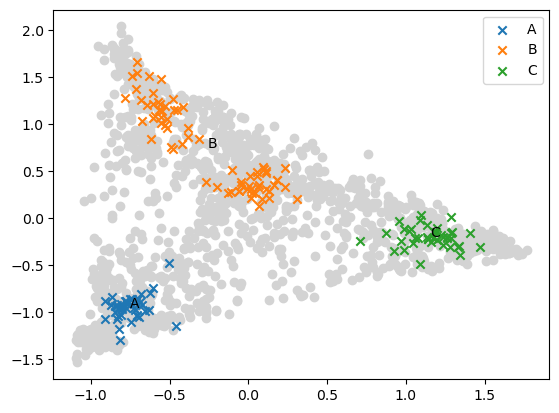

In [15]:
plt.scatter(users_ca_coords[0], users_ca_coords[1], color='lightgrey', marker='o')

for p in mps.party.unique():
    mps_ca_coords_p = mps_ca_coords[mps_ca_coords.party==p]
    x, y = mps_ca_coords_p[0], mps_ca_coords_p[1]
    plt.scatter(x, y, marker='x',label=p)
    plt.text(x=x.mean(), y=y.mean(), s=p)

plt.legend(loc='best')

In [16]:
ches = pd.DataFrame({'party': ['A','B','C'],
        'lrgen': [2,5,8],
        'eu_position': [3,6,9]})

In [17]:
ches

,party,lrgen,eu_position
0,A,2,3
1,B,5,6
2,C,8,9


In [18]:
party_ca_coords = mps_ca_coords.groupby('party').agg({0:'mean', 1:'mean'}).reset_index()

In [19]:
party_ca_coords

,party,0,1
0,A,-0.751,-0.950
1,B,-0.258,0.746
2,C,1.152,-0.205


In [20]:
political_dimension = ['lrgen', 'eu_position']
n_dim = len(political_dimension)

# matrix of party coordinates in latent space, shape PxN
X = party_ca_coords.drop(columns=['party']).values

# ridge reg on each CHES dim separately
ridge = dict()
for m in range(n_dim):
    Y = ches[political_dimension[m]].values
    ridge[m] = linear_model.Ridge(alpha=1)
    ridge[m].fit(X,Y)

In [21]:
# apply to MPs
X_mp = mps_ca_coords[[0,1]].values
df_mp_ches = pd.DataFrame(mps_ca_coords[['id','party']])
for m in range(n_dim):
    mp_ches_coordinates = ridge[m].predict(X_mp)
    df_mp_ches[political_dimension[m]] = mp_ches_coordinates

In [22]:
# apply to users
X_user = users_ca_coords[[0,1]].values
df_user_ches = pd.DataFrame(index=users_ca_coords.index)
for m in range(n_dim):
    users_ches_coordinates = ridge[m].predict(X_user)
    df_user_ches[political_dimension[m]] = users_ches_coordinates

In [23]:
df_mp_ches

,id,party,lrgen,eu_position
0,mp_0,A,3.174,4.174
1,mp_1,A,2.670,3.670
2,mp_2,A,2.601,3.601
3,mp_3,A,2.968,3.968
4,mp_4,A,2.788,3.788
...,...,...,...,...
145,mp_145,C,7.260,8.260
146,mp_146,C,7.182,8.182
147,mp_147,C,6.977,7.977
148,mp_148,C,6.970,7.970


Show in (lrgen, eu_position)space

Text(0.5, 0, 'eu_position')

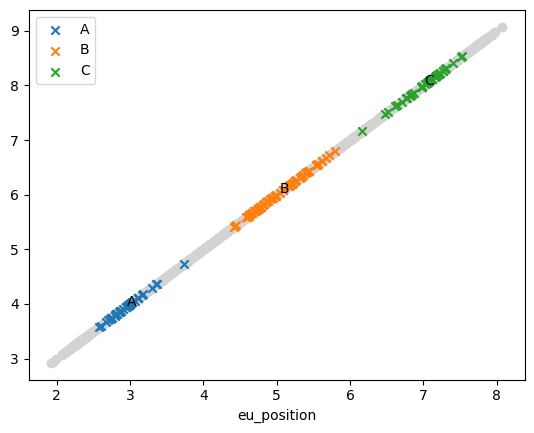

In [24]:
plt.scatter(df_user_ches['lrgen'], df_user_ches['eu_position'], color='lightgrey', marker='o')

for p in mps.party.unique():
    df_mp_ches_p = df_mp_ches[mps_ca_coords.party==p]
    x, y = df_mp_ches_p['lrgen'], df_mp_ches_p['eu_position']
    plt.scatter(x, y, marker='x',label=p)
    plt.text(x=x.mean(), y=y.mean(), s=p)

plt.legend(loc='best')
plt.xlabel('lrgen')
plt.xlabel('eu_position')

## V2

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def generate_follow_matrix(
    n_users_A=10000,
    n_users_B1=8000,
    n_users_B2=8000,
    n_users_C=10000,
    n_MPs_A=50,
    n_MPs_B1=40,
    n_MPs_B2=40,
    n_MPs_C=50,
    beta_party=5,
    beta_faction=5,
    base=0
):

    # ----------------------------
    # Latent coordinates of MPs
    # ----------------------------

    MPs = []

    # A
    MPs += [(0, 0)] * n_MPs_A

    # B1 and B2 are identical on party axis
    MPs += [(1, -1)] * n_MPs_B1
    MPs += [(1, +1)] * n_MPs_B2

    # C
    MPs += [(2, 0)] * n_MPs_C

    MPs = np.array(MPs)


    # ----------------------------
    # Latent coordinates of users
    # ----------------------------

    users = []

    # A users
    users += [(0 + np.random.normal(0, .05),
               0 + np.random.normal(0, .5))
              for _ in range(n_users_A)]

    # B1 users
    users += [(1 + np.random.normal(0, .05),
               -1 + np.random.normal(0, .2))
              for _ in range(n_users_B1)]

    # B users
    users += [(1 + np.random.normal(0, .05),
               0 + np.random.normal(0, 1))
               for _ in range(n_users_B1)]

    # B2 users
    users += [(1 + np.random.normal(0, .05),
               +1 + np.random.normal(0, .2))
              for _ in range(n_users_B2)]

    # C users
    users += [(2 + np.random.normal(0, .05),
               0 + np.random.normal(0, .5))
              for _ in range(n_users_C)]


    users = np.array(users)


    # ----------------------------
    # Compute distances
    # ----------------------------

    # party distance
    party_dist = np.abs(
        users[:, None, 0] -
        MPs[None, :, 0]
    )

    # faction distance
    faction_dist = np.abs(
        users[:, None, 1] -
        MPs[None, :, 1]
    )


    # probability of following
    logits = (
        base
        - beta_party * party_dist
        - beta_faction * faction_dist
    )

    P = sigmoid(logits)


    # sample Bernoulli matrix
    follow = np.random.random(P.shape) < P

    return follow.astype(np.int8), users, MPs

In [3]:
follow, users, MPs = generate_follow_matrix(base=0)

print(follow.shape)

(44000, 180)


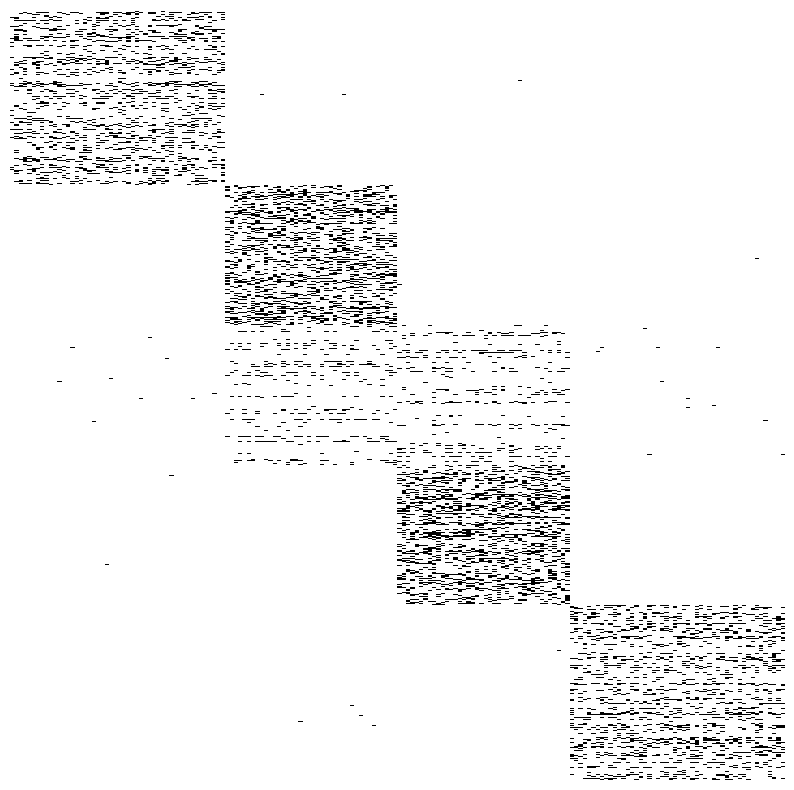

In [4]:

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    follow,
    cmap="gray_r",
    aspect="auto",
    interpolation="none"
)

ax.axis("off")
plt.show()

In [5]:
follow = pd.DataFrame(data=follow, 
                      index=[f'user_{i}' for i in range(follow.shape[0])],
                      columns=[f'mp_{i}' for i in range(follow.shape[1])])

In [6]:
follow = follow[follow.sum(axis=1) >= 2]

In [7]:
n_MPs_A=50
n_MPs_B1=40
n_MPs_B2=40
n_MPs_C=50

mp_party = pd.DataFrame({
    "mp_id": [f'mp_{i}' for i in range(follow.shape[1])],
    "faction": (
        ["A"]  * n_MPs_A +
        ["B1"] * n_MPs_B1 +
        ["B2"] * n_MPs_B2 +
        ["C"]  * n_MPs_C
    )
})

In [8]:
mp_party['party'] = mp_party['faction']
mp_party['party'] = mp_party['party'].map({'A':'A', 'B1':'B', 'B2':'B', 'C':'C'})

CA.

In [9]:
ca = prince.CA(n_components=2)
ca.fit(follow)

,n_components,2
,n_iter,10
,copy,True
,check_input,True
,random_state,None
,engine,'sklearn'


In [10]:
users_ca_coords = ca.row_coordinates(follow)
mps_ca_coords = ca.column_coordinates(follow)

In [11]:
mps_ca_coords = mps_ca_coords.merge(mp_party, left_index=True, right_on='mp_id', how='inner')

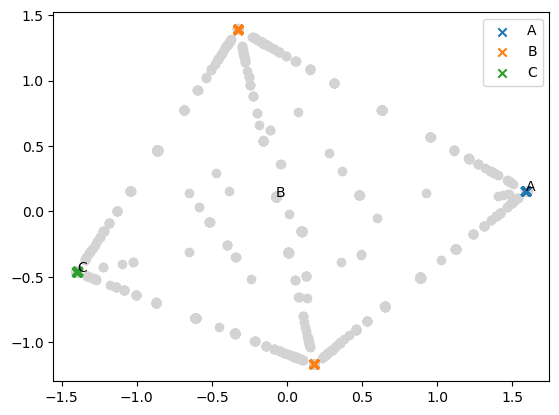

In [12]:
plt.scatter(users_ca_coords[0], users_ca_coords[1], color='lightgrey', marker='o')

for p in mp_party.party.unique():
    mps_ca_coords_p = mps_ca_coords[mps_ca_coords.party==p]
    x, y = mps_ca_coords_p[0], mps_ca_coords_p[1]
    plt.scatter(x, y, marker='x',label=p)
    plt.text(x=x.mean(), y=y.mean(), s=p)

plt.legend(loc='best')

In [13]:
ches = pd.DataFrame({'party': ['A','B','C'],
        'lrgen': [2,5,8],
        'eu_position': [4,1,6]})

In [14]:
ches

,party,lrgen,eu_position
0,A,2,4
1,B,5,1
2,C,8,6


In [15]:
party_ca_coords = mps_ca_coords.groupby('party').agg({0:'mean', 1:'mean'}).reset_index()

In [16]:
party_ca_coords

,party,0,1
0,A,1.590,0.157
1,B,-0.075,0.114
2,C,-1.397,-0.461


In [17]:
political_dimension = ['lrgen', 'eu_position']
n_dim = len(political_dimension)

# matrix of party coordinates in latent space, shape PxN
X = party_ca_coords.drop(columns=['party']).values

# ridge reg on each CHES dim separately
ridge = dict()
for dim in political_dimension:
    Y = ches[dim].values
    ridge[dim] = linear_model.Ridge(alpha=1)
    ridge[dim].fit(X,Y)

In [18]:
# apply to MPs
X_mp = mps_ca_coords[[0,1]].values
df_mp_ches = pd.DataFrame(mps_ca_coords[['mp_id','party']])
for dim in political_dimension:
    mp_ches_coordinates = ridge[dim].predict(X_mp)
    df_mp_ches[dim] = mp_ches_coordinates

In [19]:
# apply to users
X_user = users_ca_coords[[0,1]].values
df_user_ches = pd.DataFrame(index=users_ca_coords.index)
for dim in political_dimension:
    users_ches_coordinates = ridge[dim].predict(X_user)
    df_user_ches[dim] = users_ches_coordinates

Show in (lrgen, eu_position)space

Text(0, 0.5, 'eu_position')

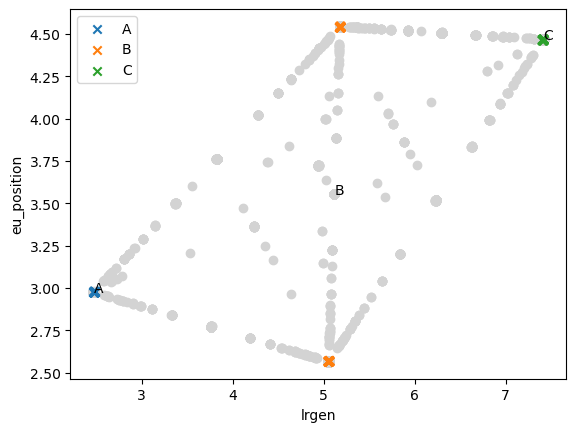

In [20]:
plt.scatter(df_user_ches['lrgen'], df_user_ches['eu_position'], color='lightgrey', marker='o')

for p in ches.party.unique():
    df_mp_ches_p = df_mp_ches[df_mp_ches.party==p]
    x, y = df_mp_ches_p['lrgen'], df_mp_ches_p['eu_position']
    plt.scatter(x, y, marker='x',label=p)
    plt.text(x=x.mean(), y=y.mean(), s=p)

plt.legend(loc='best')
plt.xlabel('lrgen')
plt.ylabel('eu_position')
#plt.ylim(-10,10)

In [21]:
functions.effective_dimensionality(df_user_ches, ['lrgen','eu_position'])

np.float64(1.6858879848996662)

In [22]:
df_user_ches[['lrgen','eu_position']].corr()

,lrgen,eu_position
lrgen,1.000,0.567
eu_position,0.567,1.000


In [23]:
functions.effective_dimensionality(df_mp_ches, ['lrgen','eu_position'])

np.float64(1.5855288061523967)

In [24]:
df_mp_ches[['lrgen','eu_position']].corr()

,lrgen,eu_position
lrgen,1.000,0.654
eu_position,0.654,1.000


In [25]:
functions.effective_dimensionality(ches, ['lrgen','eu_position'])

np.float64(1.8440766901446044)

In [26]:
ches[['lrgen','eu_position']].corr()

,lrgen,eu_position
lrgen,1.000,0.397
eu_position,0.397,1.000


Test dimensionality with varying alpha.

In [42]:
political_dimension = ['lrgen', 'eu_position']
n_dim = len(political_dimension)

ED = {'users':list(), 'MPs':list(), 'CHES':list()}

alpha_range = np.linspace(0,1,21)

for alpha in alpha_range:

    # matrix of party coordinates in latent space, shape PxN
    X = party_ca_coords.drop(columns=['party']).values

    # ridge reg on each CHES dim separately
    ridge = dict()
    for dim in political_dimension:
        Y = ches[dim].values
        ridge[dim] = linear_model.Ridge(alpha=alpha)
        ridge[dim].fit(X,Y)

    # apply to MPs
    X_mp = mps_ca_coords[[0,1]].values
    df_mp_ches = pd.DataFrame(mps_ca_coords[['mp_id','party']])
    for dim in political_dimension:
        mp_ches_coordinates = ridge[dim].predict(X_mp)
        df_mp_ches[dim] = mp_ches_coordinates

    # apply to users
    X_user = users_ca_coords[[0,1]].values
    df_user_ches = pd.DataFrame(index=users_ca_coords.index)
    for dim in political_dimension:
        users_ches_coordinates = ridge[dim].predict(X_user)
        df_user_ches[dim] = users_ches_coordinates

    ED['users'].append(functions.effective_dimensionality(df_user_ches, ['lrgen','eu_position']))
    ED['MPs'].append(functions.effective_dimensionality(df_mp_ches, ['lrgen','eu_position']))
    ED['CHES'].append(functions.effective_dimensionality(ches, ['lrgen','eu_position']))

Text(0, 0.5, 'Effective dimensionality')

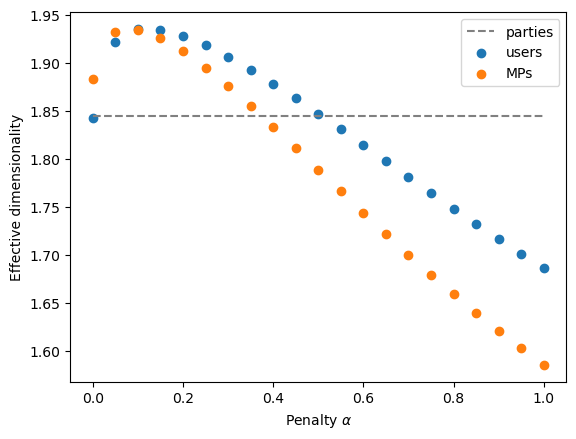

In [44]:
plt.plot(alpha_range, ED['CHES'], ls='--', color='grey', label='parties')
plt.scatter(alpha_range, ED['users'], label='users')
plt.scatter(alpha_range, ED['MPs'], label='MPs')
plt.legend(loc='best')
plt.xlabel(r'Penalty $\alpha$')
plt.ylabel('Effective dimensionality')